In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import ndimage

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from skimage import measure, morphology, filters

from kneed import KneeLocator
from tqdm import tqdm

import pandas as pd
import geopandas as gpd
import seaborn as sns
from shapely.geometry import LineString, MultiLineString

import time
import os

In [11]:
def determine_optimal_clusters(image_data, min_clusters=2, max_clusters=15, methods=None,
                              sample_size=10000, plot_results=True, standardize=True):
    """
    Determine the optimal number of clusters using various statistical methods
    
    Parameters:
    -----------
    image_data : numpy array
        Image data in shape (height, width, bands) or (height, width)
    min_clusters : int
        Minimum number of clusters to test
    max_clusters : int
        Maximum number of clusters to test
    methods : list or None
        List of methods to use: ['elbow', 'silhouette', 'calinski_harabasz', 
                                'davies_bouldin', 'gap_statistic']
        If None, uses ['elbow', 'silhouette', 'davies_bouldin']
    sample_size : int
        Number of pixels to sample for efficiency (use None to use all pixels)
    plot_results : bool
        Whether to create plots of the results
    standardize : bool
        Whether to standardize the data before clustering
        
    Returns:
    --------
    recommended_n_clusters : int
        Recommended number of clusters based on majority voting
    results : dict
        Dictionary with detailed results from each method
    """
    # Ensure image_data is at least 3D
    if len(image_data.shape) == 2:
        image_data = np.expand_dims(image_data, axis=2)
    
    # Get dimensions
    height, width, bands = image_data.shape
    
    # Flatten the image data for clustering
    pixels = image_data.reshape(-1, bands)
    
    # Remove NaN values
    valid_mask = ~np.isnan(pixels).any(axis=1)
    valid_pixels = pixels[valid_mask]
    
    print(f"Image shape: {image_data.shape}")
    print(f"Valid pixels: {len(valid_pixels)} out of {len(pixels)} ({len(valid_pixels)/len(pixels)*100:.1f}%)")
    
    # Sample pixels for efficiency if needed
    if sample_size is not None and sample_size < len(valid_pixels):
        print(f"Sampling {sample_size} pixels for analysis")
        sample_indices = np.random.choice(len(valid_pixels), sample_size, replace=False)
        sampled_pixels = valid_pixels[sample_indices]
    else:
        print(f"Using all {len(valid_pixels)} valid pixels for analysis")
        sampled_pixels = valid_pixels
    
    # Standardize data if requested
    if standardize:
        print("Standardizing data...")
        scaler = StandardScaler()
        scaled_pixels = scaler.fit_transform(sampled_pixels)
    else:
        scaled_pixels = sampled_pixels
    
    # Set default methods if not provided
    if methods is None:
        methods = ['elbow', 'silhouette', 'davies_bouldin']
    
    # Initialize results dictionary
    results = {
        'n_clusters': list(range(min_clusters, max_clusters + 1)),
        'methods': {}
    }
    
    # Set up plots if requested
    if plot_results:
        fig = plt.figure(figsize=(15, 10))
        
        # Create subplots based on number of methods
        num_methods = len(methods)
        rows = (num_methods + 1) // 2  # +1 for summary plot
        cols = 2
        
    # Run clustering for each number of clusters
    print(f"Testing cluster counts from {min_clusters} to {max_clusters}...")
    
    for method in methods:
        results['methods'][method] = {
            'values': [],
            'recommended_clusters': None
        }
    
    # Run KMeans for each cluster count
    for n_clusters in tqdm(range(min_clusters, max_clusters + 1)):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(scaled_pixels)
        
        # Calculate metrics for each method
        for method in methods:
            if method == 'elbow':
                # Lower is better
                inertia = kmeans.inertia_
                results['methods']['elbow']['values'].append(inertia)
                
            elif method == 'silhouette':
                # Higher is better
                if n_clusters > 1:  # Silhouette requires at least 2 clusters
                    silhouette_avg = silhouette_score(scaled_pixels, cluster_labels)
                    results['methods']['silhouette']['values'].append(silhouette_avg)
                else:
                    results['methods']['silhouette']['values'].append(0)
                    
            elif method == 'calinski_harabasz':
                # Higher is better
                if n_clusters > 1:  # CH requires at least 2 clusters
                    ch_score = calinski_harabasz_score(scaled_pixels, cluster_labels)
                    results['methods']['calinski_harabasz']['values'].append(ch_score)
                else:
                    results['methods']['calinski_harabasz']['values'].append(0)
                    
            elif method == 'davies_bouldin':
                # Lower is better
                if n_clusters > 1:  # DB requires at least 2 clusters
                    db_score = davies_bouldin_score(scaled_pixels, cluster_labels)
                    results['methods']['davies_bouldin']['values'].append(db_score)
                else:
                    results['methods']['davies_bouldin']['values'].append(float('inf'))
                    
            elif method == 'gap_statistic':
                # Higher is better, but computationally expensive
                # This is a simplified version
                gap = gap_statistic_simplified(scaled_pixels, kmeans, n_clusters)
                results['methods']['gap_statistic']['values'].append(gap)
    
    # Determine the optimal number of clusters for each method
    recommendations = {}
    
    for method in methods:
        values = results['methods'][method]['values']
        
        if method in ['elbow', 'davies_bouldin']:
            # For these methods, lower is better, look for the "elbow"
            try:
                kneedle = KneeLocator(
                    range(min_clusters, max_clusters + 1),
                    values,
                    curve='convex',  # OR 'concave' for methods where higher is better
                    direction='decreasing'  # OR 'increasing' for methods where higher is better
                )
                optimal = kneedle.elbow
                
                # If knee detection fails, use the minimum
                if optimal is None:
                    optimal = min_clusters + np.argmin(values)
                
            except Exception as e:
                print(f"Warning: Knee detection failed for {method}: {e}")
                optimal = min_clusters + np.argmin(values)
                
        elif method in ['silhouette', 'calinski_harabasz', 'gap_statistic']:
            # For these methods, higher is better
            optimal = min_clusters + np.argmax(values)
        
        results['methods'][method]['recommended_clusters'] = optimal
        recommendations[method] = optimal
    
    # Create a summary of recommendations
    print("\nRecommended number of clusters by method:")
    for method, n_clusters in recommendations.items():
        print(f"  {method}: {n_clusters}")
    
    # Determine the most recommended number of clusters by majority vote
    recommendation_counts = {}
    for n_clusters in recommendations.values():
        if n_clusters not in recommendation_counts:
            recommendation_counts[n_clusters] = 0
        recommendation_counts[n_clusters] += 1
    
    # Find the most common recommendation
    recommended_n_clusters = max(recommendation_counts.items(), key=lambda x: x[1])[0]
    
    print(f"\nFINAL RECOMMENDATION: {recommended_n_clusters} clusters "
          f"(supported by {recommendation_counts[recommended_n_clusters]}/{len(methods)} methods)")
    
    # Create plots if requested
    if plot_results:
        plot_idx = 1
        
        # Plot each method's results
        for method in methods:
            plt.subplot(rows, cols, plot_idx)
            plot_idx += 1
            
            values = results['methods'][method]['values']
            optimal = results['methods'][method]['recommended_clusters']
            
            # Choose the right direction (minimize vs maximize)
            if method in ['elbow', 'davies_bouldin']:
                # Lower is better
                best_idx = np.argmin(values)
                ylabel = f"{method.replace('_', ' ').title()} (lower is better)"
            else:
                # Higher is better
                best_idx = np.argmax(values)
                ylabel = f"{method.replace('_', ' ').title()} (higher is better)"
            
            # Create the plot
            plt.plot(range(min_clusters, max_clusters + 1), values, 'o-')
            plt.xlabel('Number of Clusters')
            plt.ylabel(ylabel)
            plt.title(f"{method.replace('_', ' ').title()}: {optimal} clusters")
            plt.grid(True, alpha=0.3)
            
            # Highlight optimal point
            plt.plot(optimal, values[optimal - min_clusters], 'ro', markersize=10, markeredgecolor='black')
        
        # Add a summary plot showing recommendations
        plt.subplot(rows, cols, plot_idx)
        
        # Create a bar chart of recommendations
        rec_clusters = list(recommendation_counts.keys())
        rec_counts = list(recommendation_counts.values())
        
        # Sort by number of clusters
        sorted_indices = np.argsort(rec_clusters)
        rec_clusters = [rec_clusters[i] for i in sorted_indices]
        rec_counts = [rec_counts[i] for i in sorted_indices]
        
        bars = plt.bar(rec_clusters, rec_counts)
        
        # Highlight the final recommendation
        for i, cluster in enumerate(rec_clusters):
            if cluster == recommended_n_clusters:
                bars[i].set_color('red')
                bars[i].set_edgecolor('black')
            else:
                bars[i].set_color('lightgray')
        
        plt.xlabel('Number of Clusters')
        plt.ylabel('Number of Methods Recommending')
        plt.title(f'Final Recommendation: {recommended_n_clusters} clusters')
        plt.xticks(rec_clusters)
        plt.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return recommended_n_clusters, results

def gap_statistic_simplified(data, kmeans_model, k, n_refs=5):
    """
    Simplified implementation of the gap statistic
    
    Parameters:
    -----------
    data : array-like
        The input data
    kmeans_model : KMeans object
        The fitted KMeans model
    k : int
        Number of clusters
    n_refs : int
        Number of reference datasets to generate
        
    Returns:
    --------
    gap : float
        The gap statistic value
    """
    # Inertia of the fitted model
    ref_inertia = kmeans_model.inertia_
    
    # Generate reference datasets from uniform distribution
    ref_inertias = []
    for i in range(n_refs):
        # Create a reference dataset with the same bounds as the original
        min_vals = np.min(data, axis=0)
        max_vals = np.max(data, axis=0)
        
        ref_data = np.random.uniform(
            low=min_vals,
            high=max_vals,
            size=data.shape
        )
        
        # Cluster the reference dataset
        ref_kmeans = KMeans(n_clusters=k, random_state=42, n_init=1)
        ref_kmeans.fit(ref_data)
        ref_inertias.append(ref_kmeans.inertia_)
    
    # Calculate gap statistic
    # We use log scale and compare to reference data
    gap = np.mean(np.log(ref_inertias)) - np.log(ref_inertia)
    return gap

def cluster_analysis_full_workflow(image_data, min_clusters=2, max_clusters=10,
                                  sample_size=10000, standardize=True, methods_list=['elbow', 'silhouette', 'davies_bouldin']):
    """
    Full workflow for cluster analysis and determination of optimal cluster count
    
    Parameters:
    -----------
    image_data : numpy array
        Image data in shape (height, width, bands) or (height, width)
    min_clusters : int
        Minimum number of clusters to test
    max_clusters : int
        Maximum number of clusters to test
    sample_size : int
        Number of pixels to sample for efficiency
    standardize : bool
        Whether to standardize the data before clustering
        
    Returns:
    --------
    optimal_clusters : int
        Optimal number of clusters
    kmeans_model : KMeans model
        Fitted KMeans model with optimal number of clusters
    clustered_image : numpy array
        Image with cluster assignments
    """
    # Step 1: Determine optimal number of clusters
    optimal_clusters, _ = determine_optimal_clusters(
        image_data, 
        min_clusters=min_clusters, 
        max_clusters=max_clusters,
        methods=methods_list,
        sample_size=sample_size,
        plot_results=True,
        standardize=standardize
    )
    
    # Step 2: Perform clustering with the optimal number
    print(f"\nPerforming final clustering with {optimal_clusters} clusters...")
    
    # Ensure image_data is at least 3D
    if len(image_data.shape) == 2:
        image_data = np.expand_dims(image_data, axis=2)
    
    # Get dimensions
    height, width, bands = image_data.shape
    
    # Flatten the image for clustering
    pixels = image_data.reshape(-1, bands)
    
    # Keep track of valid pixels
    valid_mask = ~np.isnan(pixels).any(axis=1)
    valid_pixels = pixels[valid_mask]
    
    # Standardize if requested
    if standardize:
        scaler = StandardScaler()
        scaled_pixels = scaler.fit_transform(valid_pixels)
    else:
        scaled_pixels = valid_pixels
    
    # Perform final clustering
    kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
    valid_labels = kmeans.fit_predict(scaled_pixels)
    
    # Create output clustered image (with NaN preserved)
    clustered_image = np.full((height * width), np.nan)
    clustered_image[valid_mask] = valid_labels
    clustered_image = clustered_image.reshape((height, width))
    
    # Visualize the clusters
    plt.figure(figsize=(12, 10))
    
    # Create a masked array for visualization
    clustered_masked = np.ma.array(clustered_image, mask=np.isnan(clustered_image))
    
    # Use a good colormap for the number of clusters
    if optimal_clusters <= 10:
        cmap = 'tab10'
    elif optimal_clusters <= 20:
        cmap = 'tab20'
    else:
        cmap = 'nipy_spectral'
    
    plt.imshow(clustered_masked, cmap=cmap, interpolation='nearest')
    plt.colorbar(label='Cluster')
    plt.title(f'K-means Clustering with {optimal_clusters} clusters')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Step 3: Analyze the cluster statistics
    cluster_stats = analyze_cluster_statistics(
        image_data, clustered_image, standardize=standardize
    )
    
    return optimal_clusters, kmeans, clustered_image, cluster_stats

def analyze_cluster_statistics(image_data, cluster_map, standardize=True):
    """
    Analyze and visualize statistics of clusters
    
    Parameters:
    -----------
    image_data : numpy array
        Original image data in shape (height, width, bands) or (height, width)
    cluster_map : numpy array
        Cluster assignments in shape (height, width)
    standardize : bool
        Whether to show standardized values in plots
        
    Returns:
    --------
    cluster_stats : dict
        Dictionary of statistics for each cluster
    """
    # Ensure image_data is at least 3D
    if len(image_data.shape) == 2:
        image_data = np.expand_dims(image_data, axis=2)
    
    # Get dimensions
    height, width, bands = image_data.shape
    
    # Find unique clusters
    unique_clusters = np.unique(cluster_map[~np.isnan(cluster_map)])
    num_clusters = len(unique_clusters)
    
    print(f"Analyzing statistics for {num_clusters} clusters...")
    
    # Initialize stats dictionary
    cluster_stats = {
        'overall': {
            'count': np.sum(~np.isnan(cluster_map)),
            'bands': {}
        },
        'clusters': {}
    }
    
    # Compute overall stats for standardization reference
    for b in range(bands):
        band_data = image_data[:,:,b]
        valid_mask = ~np.isnan(band_data)
        valid_data = band_data[valid_mask]
        
        cluster_stats['overall']['bands'][b] = {
            'mean': np.mean(valid_data),
            'std': np.std(valid_data),
            'min': np.min(valid_data),
            'max': np.max(valid_data)
        }
    
    # Compute statistics for each cluster
    for cluster_id in unique_clusters:
        # Create mask for this cluster
        cluster_mask = (cluster_map == cluster_id)
        
        # Count pixels in this cluster
        pixel_count = np.sum(cluster_mask)
        
        # Initialize cluster stats
        cluster_stats['clusters'][cluster_id] = {
            'count': pixel_count,
            'percentage': pixel_count / cluster_stats['overall']['count'] * 100,
            'bands': {}
        }
        
        # Compute stats for each band
        for b in range(bands):
            band_data = image_data[:,:,b]
            
            # Get band data for this cluster
            cluster_band_data = band_data[cluster_mask]
            
            # Filter out NaN values
            valid_mask = ~np.isnan(cluster_band_data)
            valid_data = cluster_band_data[valid_mask]
            
            if len(valid_data) > 0:
                # Calculate statistics
                mean_val = np.mean(valid_data)
                median_val = np.median(valid_data)
                std_val = np.std(valid_data)
                min_val = np.min(valid_data)
                max_val = np.max(valid_data)
                
                # Store raw statistics
                cluster_stats['clusters'][cluster_id]['bands'][b] = {
                    'mean': mean_val,
                    'median': median_val,
                    'std': std_val,
                    'min': min_val,
                    'max': max_val,
                    'valid_count': len(valid_data)
                }
                
                # Compute standardized values if requested
                if standardize:
                    overall_mean = cluster_stats['overall']['bands'][b]['mean']
                    overall_std = cluster_stats['overall']['bands'][b]['std']
                    
                    cluster_stats['clusters'][cluster_id]['bands'][b]['z_mean'] = (mean_val - overall_mean) / overall_std
                    cluster_stats['clusters'][cluster_id]['bands'][b]['z_median'] = (median_val - overall_mean) / overall_std
    
    # Create visualizations
    
    # 1. Bar chart of cluster sizes
    plt.figure(figsize=(12, 6))
    
    # Get cluster sizes
    cluster_ids = sorted(cluster_stats['clusters'].keys())
    cluster_sizes = [cluster_stats['clusters'][c]['percentage'] for c in cluster_ids]
    
    # Plot
    plt.bar(cluster_ids, cluster_sizes)
    plt.xlabel('Cluster')
    plt.ylabel('Percentage of Image (%)')
    plt.title('Cluster Size Distribution')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(cluster_ids)
    
    # Add text labels
    for i, v in enumerate(cluster_sizes):
        plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # 2. Heatmap of mean values by band and cluster
    plt.figure(figsize=(12, 8))
    
    # Prepare data for the heatmap
    heatmap_data = []
    for cluster_id in cluster_ids:
        row = []
        for b in range(bands):
            if standardize:
                # Use standardized values
                row.append(cluster_stats['clusters'][cluster_id]['bands'][b]['z_mean'])
            else:
                # Use raw values
                row.append(cluster_stats['clusters'][cluster_id]['bands'][b]['mean'])
        heatmap_data.append(row)
    
    # Convert to numpy array
    heatmap_array = np.array(heatmap_data)
    
    # Create heatmap
    ax = sns.heatmap(
        heatmap_array, 
        annot=True, 
        fmt='.2f', 
        cmap='viridis',
        xticklabels=[f'Band {b+1}' for b in range(bands)],
        yticklabels=[f'Cluster {c}' for c in cluster_ids]
    )
    
    plt.xlabel('Band')
    plt.ylabel('Cluster')
    
    if standardize:
        plt.title('Standardized Mean Values by Cluster and Band (z-scores)')
    else:
        plt.title('Mean Values by Cluster and Band')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Parallel coordinates plot for cluster characteristics
    if bands >= 2:
        plt.figure(figsize=(12, 8))
        
        # Prepare data for parallel coordinates
        parallel_data = []
        for cluster_id in cluster_ids:
            for b in range(bands):
                if standardize:
                    value = cluster_stats['clusters'][cluster_id]['bands'][b]['z_mean']
                else:
                    value = cluster_stats['clusters'][cluster_id]['bands'][b]['mean']
                
                parallel_data.append({
                    'Cluster': f'Cluster {cluster_id}',
                    'Band': f'Band {b+1}',
                    'Value': value
                })
        
        # Convert to DataFrame
        df = pd.DataFrame(parallel_data)
        
        # Create parallel coordinates plot
        sns.lineplot(
            data=df,
            x='Band',
            y='Value',
            hue='Cluster',
            marker='o',
            markersize=8,
            linewidth=2
        )
        
        plt.grid(True, alpha=0.3)
        
        if standardize:
            plt.ylabel('Standardized Value (z-score)')
            plt.title('Cluster Profiles Across Bands (Standardized)')
        else:
            plt.ylabel('Value')
            plt.title('Cluster Profiles Across Bands')
            
        plt.tight_layout()
        plt.show()
    
    return cluster_stats

def plot_sar_cluster_histograms(sar_data, cluster_map, log_scale=False, sample_size=10000, 
                                figsize=(15, 10), dB_scale=True, data_already_in_db=False, 
                                bins=50, verbose=False):
    """
    Plot histograms of SAR values for each cluster with appropriate scaling
    
    Parameters:
    -----------
    sar_data : numpy array
        SAR image data, shape (height, width) or (height, width, bands)
    cluster_map : numpy array
        Cluster assignments, shape (height, width)
    log_scale : bool, optional
        Whether to use logarithmic scale for histogram x-axis
    sample_size : int, optional
        Number of random pixels to sample from each cluster
    figsize : tuple, optional
        Figure size (width, height)
    dB_scale : bool, optional
        Whether to convert intensity values to dB (10*log10(intensity))
        Ignored if data_already_in_db is True
    data_already_in_db : bool, optional
        Whether the input SAR data is already in dB units
    bins : int or array, optional
        Number of histogram bins or bin edges array
    verbose : bool, optional
        Whether to print detailed debugging information
    """
    # Set up print function based on verbosity
    def debug_print(*args, **kwargs):
        if verbose:
            print(*args, **kwargs)
    
    # Ensure consistent dimensions for SAR data
    if len(sar_data.shape) == 2:
        # Single band - reshape to 3D for consistent processing
        sar_data = np.expand_dims(sar_data, axis=2)
        debug_print(f"Expanded single-band data to shape: {sar_data.shape}")
    
    # Check input dimensions
    if sar_data.shape[0] != cluster_map.shape[0] or sar_data.shape[1] != cluster_map.shape[1]:
        raise ValueError(f"sar_data shape {sar_data.shape[:2]} and cluster_map shape {cluster_map.shape} must have matching spatial dimensions")
    
    # Get number of bands
    num_bands = sar_data.shape[2]
    debug_print(f"Number of bands detected: {num_bands}")
    
    # Set polarization names based on number of bands
    if num_bands == 1:
        pol_names = ['Intensity']
    elif num_bands == 2:
        pol_names = ['HH', 'HV']  # Common dual-pol configuration
    elif num_bands == 4:
        pol_names = ['HH', 'HV', 'VH', 'VV']  # Quad-pol configuration
    else:
        pol_names = [f'Band_{i+1}' for i in range(num_bands)]
    
    debug_print(f"Using polarization names: {pol_names}")
    
    # Find unique clusters, excluding NaN values
    valid_pixels_mask = ~np.isnan(cluster_map)
    unique_clusters = np.unique(cluster_map[valid_pixels_mask]).astype(int)
    num_clusters = len(unique_clusters)
    
    debug_print(f"Found {num_clusters} unique clusters: {unique_clusters}")
    debug_print(f"Valid (non-NaN) pixels in cluster map: {np.sum(valid_pixels_mask)} out of {cluster_map.size}")
    
    # Create colormap for clusters
    if num_clusters <= 10:
        cmap = plt.cm.get_cmap('tab10', num_clusters)
    elif num_clusters <= 20:
        cmap = plt.cm.get_cmap('tab20', num_clusters)
    else:
        cmap = plt.cm.get_cmap('nipy_spectral', num_clusters)
    
    colors = [cmap(i) for i in range(num_clusters)]
    
    # Create figures - one for each band
    figs = []
    
    # Process each band separately
    for b in range(num_bands):
        # Create figure for this band
        fig = plt.figure(figsize=figsize)
        figs.append(fig)
        
        # Extract this band's data
        band_data = sar_data[:,:,b]
        
        debug_print(f"\nProcessing {pol_names[b]}:")
        debug_print(f"  Band data shape: {band_data.shape}")
        debug_print(f"  Band data range: {np.nanmin(band_data)} to {np.nanmax(band_data)}")
        debug_print(f"  Band data has NaNs: {np.any(np.isnan(band_data))}")
        debug_print(f"  Band data has Infs: {np.any(np.isinf(band_data))}")
        
        # Sample data from each cluster for this band
        cluster_samples = {}
        cluster_counts = {}
        
        debug_print(f"\nSampling clusters for {pol_names[b]}:")
        
        # Process each cluster
        for i, cluster_id in enumerate(unique_clusters):
            # Create mask for this cluster (must use == for exact comparison)
            cluster_mask = (cluster_map == cluster_id)
            total_pixels = np.sum(cluster_mask)
            
            debug_print(f"\n  Cluster {cluster_id}:")
            debug_print(f"    Total pixels in cluster: {total_pixels}")
            
            # Check if we have any pixels in this cluster
            if total_pixels == 0:
                debug_print(f"    WARNING: No pixels found in cluster {cluster_id}")
                cluster_counts[cluster_id] = {'total': 0, 'valid': 0, 'invalid': 0}
                cluster_samples[cluster_id] = np.array([])
                continue
            
            # Extract all pixel values for this cluster
            cluster_pixels = band_data[cluster_mask]
            
            debug_print(f"    Extracted {len(cluster_pixels)} pixels")
            debug_print(f"    Pixel value range: {np.nanmin(cluster_pixels)} to {np.nanmax(cluster_pixels)}")
            debug_print(f"    Pixels with NaNs: {np.sum(np.isnan(cluster_pixels))}")
            debug_print(f"    Pixels with Infs: {np.sum(np.isinf(cluster_pixels))}")
            
            # Create a mask for valid pixels based on filtering criteria
            if data_already_in_db:
                # For data already in dB, we just need to exclude NaN and Inf
                valid_mask = ~np.isnan(cluster_pixels) & ~np.isinf(cluster_pixels)
            elif log_scale or dB_scale:
                # For log or dB conversion, we need positive values
                valid_mask = (cluster_pixels > 0) & ~np.isnan(cluster_pixels) & ~np.isinf(cluster_pixels)
            else:
                # For linear scale, just exclude NaN and Inf
                valid_mask = ~np.isnan(cluster_pixels) & ~np.isinf(cluster_pixels)
            
            valid_count = np.sum(valid_mask)
            debug_print(f"    Valid pixels: {valid_count} ({valid_count/len(cluster_pixels)*100:.1f}%)")
            
            # Store counts for reporting
            cluster_counts[cluster_id] = {
                'total': len(cluster_pixels),
                'valid': valid_count,
                'invalid': len(cluster_pixels) - valid_count
            }
            
            # Extract valid pixel values
            if valid_count > 0:
                valid_pixels = cluster_pixels[valid_mask]
                
                # Sample pixels if needed
                if valid_count > sample_size:
                    sample_indices = np.random.choice(valid_count, sample_size, replace=False)
                    sampled_pixels = valid_pixels[sample_indices]
                    debug_print(f"    Sampled {sample_size} pixels from {valid_count} valid pixels")
                else:
                    sampled_pixels = valid_pixels
                    debug_print(f"    Using all {valid_count} valid pixels (below sample size)")
                
                # Convert to dB if requested and not already in dB
                if dB_scale and not data_already_in_db:
                    # Ensure positive values before log
                    positive_mask = sampled_pixels > 0
                    if np.all(positive_mask):
                        sampled_pixels = 10 * np.log10(sampled_pixels)
                    else:
                        debug_print(f"    WARNING: {np.sum(~positive_mask)} non-positive values found when converting to dB")
                        sampled_pixels = 10 * np.log10(sampled_pixels[positive_mask])
                
                # Store samples
                cluster_samples[cluster_id] = sampled_pixels
            else:
                debug_print(f"    WARNING: No valid pixels in cluster {cluster_id} for {pol_names[b]}")
                cluster_samples[cluster_id] = np.array([])
        
        # Check if we have any valid samples across all clusters
        all_samples = np.concatenate([samples for samples in cluster_samples.values() if len(samples) > 0])
        
        if len(all_samples) == 0:
            debug_print(f"WARNING: No valid data for {pol_names[b]}. Skipping histogram.")
            plt.text(0.5, 0.5, f"No valid data for {pol_names[b]}", 
                    horizontalalignment='center', verticalalignment='center',
                    transform=plt.gca().transAxes, fontsize=14)
            plt.title(f'{pol_names[b]} - No Valid Data')
            continue
        
        # Compute histogram bins
        if isinstance(bins, int):
            if log_scale and not data_already_in_db:
                # Create logarithmic bins
                min_val = np.min(all_samples)
                max_val = np.max(all_samples)
                if min_val <= 0:
                    min_val = max_val * 1e-5  # Small positive value
                hist_bins = np.logspace(np.log10(min_val), np.log10(max_val), bins)
                debug_print(f"  Created {len(hist_bins)-1} logarithmic bins from {min_val} to {max_val}")
            else:
                # Create regular bins
                min_val = np.min(all_samples)
                max_val = np.max(all_samples)
                hist_bins = np.linspace(min_val, max_val, bins)
                debug_print(f"  Created {len(hist_bins)-1} linear bins from {min_val} to {max_val}")
        else:
            # Use provided bins
            hist_bins = bins
            debug_print(f"  Using {len(hist_bins)-1} provided bins")
        
        # Plot histograms for each cluster
        debug_print("\nCreating histograms:")
        for i, cluster_id in enumerate(unique_clusters):
            samples = cluster_samples[cluster_id]
            
            if len(samples) == 0:
                debug_print(f"  Skipping cluster {cluster_id} - no valid samples")
                continue
            
            debug_print(f"  Plotting histogram for cluster {cluster_id} with {len(samples)} samples")
            
            # Calculate histogram
            try:
                hist, bin_edges = np.histogram(samples, bins=hist_bins, density=True)
                plt.hist(samples, bins=hist_bins, alpha=0.5, density=True,
                        color=colors[i], label=f'Cluster {cluster_id} (n={cluster_counts[cluster_id]["valid"]})')
            except Exception as e:
                debug_print(f"  ERROR plotting histogram for cluster {cluster_id}: {e}")
        
        # Set labels and title
        if data_already_in_db or dB_scale:
            plt.xlabel('Backscatter Intensity (dB)')
        else:
            plt.xlabel('Backscatter Intensity')
            
        plt.ylabel('Density')
        
        # Set the appropriate title
        if data_already_in_db:
            title_suffix = "(dB Scale)"
        elif log_scale:
            plt.xscale('log')
            title_suffix = "(Log Scale)"
        elif dB_scale:
            title_suffix = "(dB Scale)"
        else:
            title_suffix = "(Linear Scale)"
        
        plt.title(f'{pol_names[b]} Distribution by Cluster {title_suffix}')
        
        # Add legend
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
    
    # Print statistics summary
    debug_print("\nCluster Statistics Summary:")
    debug_print("Cluster | Total Pixels | Valid Pixels | % Valid")
    debug_print("--------|--------------|--------------|--------")
    
    for cluster_id in unique_clusters:
        if cluster_id in cluster_counts:  # Check if this cluster has data
            total_count = cluster_counts[cluster_id]['total']
            valid_count = cluster_counts[cluster_id]['valid']
            
            # Calculate percentage
            if total_count > 0:
                percent_valid = (valid_count / total_count) * 100
            else:
                percent_valid = 0
                
            debug_print(f"{cluster_id:7d} | {total_count:12d} | {valid_count:12d} | {percent_valid:6.2f}%")
    
    # Create visualizations of the clusters and original SAR data
    # 1. Cluster map visualization
    plt.figure(figsize=(10, 8))
    
    # Create masked array for visualization
    cluster_map_masked = np.ma.array(cluster_map, mask=np.isnan(cluster_map))
    
    # Plot clusters
    plt.imshow(cluster_map_masked, cmap=cmap, interpolation='nearest')
    cbar = plt.colorbar(label='Cluster')
    
    # Add ticks for each cluster
    cbar.set_ticks(unique_clusters)
    
    plt.title('Spatial Distribution of Clusters')
    plt.axis('off')
    plt.tight_layout()
    
    # 2. SAR data visualization (first band)
    plt.figure(figsize=(10, 8))
    
    # Get first band for visualization
    first_band = sar_data[:,:,0]
    
    # Check for valid values in the first band
    if np.any(~np.isnan(first_band) & ~np.isinf(first_band)):
        # Replace inf and NaN with zeros for visualization
        first_band_clean = np.nan_to_num(first_band, nan=0.0, posinf=0.0, neginf=0.0)
        
        # Create visualization depending on data type
        if data_already_in_db:
            # For data already in dB, use it directly
            plt.imshow(first_band_clean, cmap='gray')
            plt.title(f'SAR Intensity - {pol_names[0]} (dB Scale)')
            plt.colorbar(label='Intensity (dB)')
        else:
            # For linear data, apply log scale for better visualization
            if np.max(first_band_clean) > 0:
                # Add small constant to avoid log(0)
                log_band = np.log10(first_band_clean + 1e-6)
                plt.imshow(log_band, cmap='gray')
                plt.title(f'SAR Intensity - {pol_names[0]} (Log Scale)')
                plt.colorbar(label='Log Intensity')
            else:
                plt.imshow(first_band_clean, cmap='gray')
                plt.title(f'SAR Intensity - {pol_names[0]}')
                plt.colorbar(label='Intensity')
    else:
        plt.text(0.5, 0.5, "No valid data in first band", 
                horizontalalignment='center', verticalalignment='center',
                transform=plt.gca().transAxes, fontsize=14)
        plt.title(f'SAR Intensity - {pol_names[0]} (No Valid Data)')
    
    plt.axis('off')
    plt.tight_layout()
    
    # Return useful information
    return {
        'figures': figs,
        'cluster_counts': cluster_counts,
        'unique_clusters': unique_clusters,
        'pol_names': pol_names
    }

def plot_db_sar_cluster_histograms(db_sar_data, cluster_map, sample_size=10000, 
                                  figsize=(15, 10), bins=50):
    """
    Plot histograms for SAR data that's already in dB units
    
    Parameters:
    -----------
    db_sar_data : numpy array
        SAR image data in dB units, shape (height, width) or (height, width, bands)
    cluster_map : numpy array
        Cluster assignments, shape (height, width)
    sample_size : int, optional
        Number of random pixels to sample from each cluster
    figsize : tuple, optional
        Figure size (width, height)
    bins : int or array, optional
        Number of histogram bins or bin edges array
        
    Returns:
    --------
    stats : dict
        Dictionary with statistics for each cluster
    """
    # Ensure sar_data has a consistent shape
    if len(db_sar_data.shape) == 2:
        db_sar_data = np.expand_dims(db_sar_data, axis=2)
    
    # Find unique clusters
    unique_clusters = np.unique(cluster_map[~np.isnan(cluster_map)]).astype(int)
    num_clusters = len(unique_clusters)
    
    # Get number of bands
    num_bands = db_sar_data.shape[2]
    
    # Set polarization names based on number of bands
    if num_bands == 1:
        pol_names = ['Intensity']
    elif num_bands == 2:
        pol_names = ['HH', 'HV']
    elif num_bands == 4:
        pol_names = ['HH', 'HV', 'VH', 'VV']
    else:
        pol_names = [f'Band_{i+1}' for i in range(num_bands)]
    
    # Create colormap for clusters
    if num_clusters <= 10:
        cmap = plt.cm.get_cmap('tab10', num_clusters)
    elif num_clusters <= 20:
        cmap = plt.cm.get_cmap('tab20', num_clusters)
    else:
        cmap = plt.cm.get_cmap('nipy_spectral', num_clusters)
    
    colors = [cmap(i) for i in range(num_clusters)]
    
    # Create figures - one for each band
    figs = []
    
    # Collect statistics
    stats = {
        'clusters': {},
        'overall': {'band_stats': {}}
    }
    
    # Process each band separately
    for b in range(num_bands):
        # Get band data
        band_data = db_sar_data[:,:,b]
        band_name = pol_names[b]
        
        # Create figure for this band
        fig = plt.figure(figsize=figsize)
        figs.append(fig)
        
        # Initialize band stats in the overall stats
        stats['overall']['band_stats'][band_name] = {
            'valid_count': 0,
            'min': float('inf'),
            'max': float('-inf'),
            'all_samples': []
        }
        
        # Process each cluster
        for i, cluster_id in enumerate(unique_clusters):
            # Make sure this cluster has an entry in stats
            if cluster_id not in stats['clusters']:
                stats['clusters'][cluster_id] = {
                    'band_stats': {},
                    'total_pixels': np.sum(cluster_map == cluster_id)
                }
            
            # Initialize this band's stats for this cluster
            stats['clusters'][cluster_id]['band_stats'][band_name] = {}
            
            # Create mask for this cluster
            cluster_mask = (cluster_map == cluster_id)
            
            # Get pixels in this cluster for this band
            cluster_pixels = band_data[cluster_mask]
            
            # Filter valid pixels (non-NaN, non-Inf)
            valid_mask = ~np.isnan(cluster_pixels) & ~np.isinf(cluster_pixels)
            valid_pixels = cluster_pixels[valid_mask]
            
            # Update stats
            stats['clusters'][cluster_id]['band_stats'][band_name]['total_count'] = len(cluster_pixels)
            stats['clusters'][cluster_id]['band_stats'][band_name]['valid_count'] = len(valid_pixels)
            
            # Process valid pixels
            if len(valid_pixels) > 0:
                # Sample if needed
                if len(valid_pixels) > sample_size:
                    indices = np.random.choice(len(valid_pixels), sample_size, replace=False)
                    sampled_pixels = valid_pixels[indices]
                else:
                    sampled_pixels = valid_pixels
                
                # Calculate statistics
                stats['clusters'][cluster_id]['band_stats'][band_name].update({
                    'mean': np.mean(valid_pixels),
                    'median': np.median(valid_pixels),
                    'std': np.std(valid_pixels),
                    'min': np.min(valid_pixels),
                    'max': np.max(valid_pixels),
                    'p25': np.percentile(valid_pixels, 25),
                    'p75': np.percentile(valid_pixels, 75),
                    'sampled_values': sampled_pixels
                })
                
                # Update overall stats
                stats['overall']['band_stats'][band_name]['valid_count'] += len(valid_pixels)
                stats['overall']['band_stats'][band_name]['min'] = min(
                    stats['overall']['band_stats'][band_name]['min'], 
                    np.min(valid_pixels)
                )
                stats['overall']['band_stats'][band_name]['max'] = max(
                    stats['overall']['band_stats'][band_name]['max'], 
                    np.max(valid_pixels)
                )
                stats['overall']['band_stats'][band_name]['all_samples'].extend(sampled_pixels)
        
        # Compute common bins across all clusters for this band
        all_samples = stats['overall']['band_stats'][band_name]['all_samples']
        
        if len(all_samples) > 0:
            # Calculate bin range
            min_val = stats['overall']['band_stats'][band_name]['min']
            max_val = stats['overall']['band_stats'][band_name]['max']
            
            # Create bins
            if isinstance(bins, int):
                hist_bins = np.linspace(min_val, max_val, bins)
            else:
                hist_bins = bins
            
            # Plot histograms for each cluster
            for i, cluster_id in enumerate(unique_clusters):
                cluster_stats = stats['clusters'][cluster_id]['band_stats'][band_name]
                
                # Only plot if we have valid pixels
                if 'sampled_values' in cluster_stats and len(cluster_stats['sampled_values']) > 0:
                    plt.hist(
                        cluster_stats['sampled_values'], 
                        bins=hist_bins, 
                        alpha=0.5, 
                        density=True,
                        color=colors[i], 
                        label=f'Cluster {cluster_id} (n={cluster_stats["valid_count"]})'
                    )
            
            # Add labels and titles
            plt.xlabel('Backscatter Intensity (dB)')
            plt.ylabel('Density')
            plt.title(f'{band_name} Distribution by Cluster')
            plt.grid(True, alpha=0.3)
            plt.legend()
        else:
            plt.text(0.5, 0.5, f"No valid data for {band_name}", 
                    ha='center', va='center', transform=plt.gca().transAxes, fontsize=14)
            plt.title(f'{band_name} - No Valid Data')
        
        plt.tight_layout()
    
    # Create visualizations of the clusters and SAR data
    # 1. Cluster map visualization
    plt.figure(figsize=(10, 8))
    cluster_map_masked = np.ma.array(cluster_map, mask=np.isnan(cluster_map))
    plt.imshow(cluster_map_masked, cmap=cmap, interpolation='nearest')
    cbar = plt.colorbar(label='Cluster')
    cbar.set_ticks(unique_clusters)
    plt.title('Spatial Distribution of Clusters')
    plt.axis('off')
    
    # 2. SAR data visualization (first band)
    plt.figure(figsize=(10, 8))
    first_band = db_sar_data[:,:,0]
    first_band_clean = np.nan_to_num(first_band, nan=0.0, posinf=0.0, neginf=0.0)
    plt.imshow(first_band_clean, cmap='gray')
    plt.title(f'SAR Intensity - {pol_names[0]} (dB Scale)')
    plt.colorbar(label='Intensity (dB)')
    plt.axis('off')
    
    # Print a summary
    print("\nCluster Summary:")
    print("Cluster | Total Pixels | Valid Pixels | Mean dB")
    print("--------|--------------|-------------|--------")
    
    for cluster_id in unique_clusters:
        total_pixels = stats['clusters'][cluster_id]['total_pixels']
        
        # Average stats across bands
        band_stats = stats['clusters'][cluster_id]['band_stats']
        valid_counts = [stats['valid_count'] for stats in band_stats.values() if 'valid_count' in stats]
        mean_values = [stats['mean'] for stats in band_stats.values() if 'mean' in stats]
        
        if valid_counts and mean_values:
            avg_valid = sum(valid_counts) / len(valid_counts)
            avg_mean = sum(mean_values) / len(mean_values)
            print(f"{cluster_id:7d} | {total_pixels:12d} | {avg_valid:11.0f} | {avg_mean:6.2f}")
        else:
            print(f"{cluster_id:7d} | {total_pixels:12d} | {'N/A':11s} | {'N/A':6s}")
    
    # Return stats for further analysis
    return {
        'stats': stats,
        'figures': figs,
        'unique_clusters': unique_clusters,
        'pol_names': pol_names
    }

def select_highest_db_cluster(db_sar_data, cluster_map, bands=None, visualize=True, return_mask=False):
    """
    Analyze clusters in SAR data (already in dB) and select the one with
    highest average dB value
    
    Parameters:
    -----------
    db_sar_data : numpy array
        SAR image data in dB units, shape (height, width) or (height, width, bands)
    cluster_map : numpy array
        Cluster assignments, shape (height, width)
    bands : list or None
        Specific bands to consider, or None to use all bands
    visualize : bool
        Whether to create visualization plots
    return_mask : bool
        Whether to return a binary mask of the selected cluster
        
    Returns:
    --------
    selected_cluster : int
        ID of the cluster with highest average dB value
    cluster_stats : dict
        Statistics for all clusters
    cluster_mask : numpy array (optional)
        Binary mask of the selected cluster (if return_mask=True)
    """
    # Ensure sar_data has a consistent shape
    if len(db_sar_data.shape) == 2:
        db_sar_data = np.expand_dims(db_sar_data, axis=2)
    
    # Get number of bands
    num_bands = db_sar_data.shape[2]
    
    # Set band indices to use
    if bands is None:
        bands = list(range(num_bands))
    else:
        # Ensure bands are valid
        for b in bands:
            if b < 0 or b >= num_bands:
                raise ValueError(f"Invalid band index {b}. Must be between 0 and {num_bands-1}")
    
    # Set polarization names based on number of bands
    if num_bands == 1:
        pol_names = ['Intensity']
    elif num_bands == 2:
        pol_names = ['HH', 'HV']  # Common dual-pol configuration
    elif num_bands == 4:
        pol_names = ['HH', 'HV', 'VH', 'VV']  # Quad-pol configuration
    else:
        pol_names = [f'Band_{i+1}' for i in range(num_bands)]
    
    # Find unique clusters, excluding NaN values
    valid_mask = ~np.isnan(cluster_map)
    unique_clusters = np.unique(cluster_map[valid_mask]).astype(int)
    num_clusters = len(unique_clusters)
    
    print(f"Analyzing {num_clusters} clusters across {len(bands)} bands...")
    
    # Initialize statistics dictionary
    cluster_stats = {}
    
    # Process each cluster
    for cluster_id in unique_clusters:
        # Create mask for this cluster
        cluster_mask = (cluster_map == cluster_id)
        pixel_count = np.sum(cluster_mask)
        
        # Initialize stats for this cluster
        cluster_stats[cluster_id] = {
            'pixel_count': pixel_count,
            'bands': {},
            'mean_db': 0  # Will store the average dB across all bands
        }
        
        # Process each selected band
        band_means = []
        
        for band_idx in bands:
            # Extract band data
            band_data = db_sar_data[:,:,band_idx]
            band_name = pol_names[band_idx]
            
            # Get pixels for this cluster in this band
            cluster_pixels = band_data[cluster_mask]
            
            # Filter valid pixels (not NaN or Inf)
            valid_mask = ~np.isnan(cluster_pixels) & ~np.isinf(cluster_pixels)
            valid_pixels = cluster_pixels[valid_mask]
            
            # Calculate statistics if we have valid pixels
            if len(valid_pixels) > 0:
                mean_db = np.mean(valid_pixels)
                median_db = np.median(valid_pixels)
                std_db = np.std(valid_pixels)
                min_db = np.min(valid_pixels)
                max_db = np.max(valid_pixels)
                
                # Store statistics
                cluster_stats[cluster_id]['bands'][band_name] = {
                    'valid_count': len(valid_pixels),
                    'mean_db': mean_db,
                    'median_db': median_db,
                    'std_db': std_db,
                    'min_db': min_db,
                    'max_db': max_db
                }
                
                # Add to list of means for averaging
                band_means.append(mean_db)
        
        # Calculate average dB across all bands
        if band_means:
            cluster_stats[cluster_id]['mean_db'] = np.mean(band_means)
        else:
            cluster_stats[cluster_id]['mean_db'] = float('-inf')  # No valid data
    
    # Find the cluster with the highest average dB
    highest_db_cluster = max(cluster_stats.keys(), 
                            key=lambda k: cluster_stats[k]['mean_db'])
    
    # Print results
    print("\nCluster Statistics (Average dB values):")
    print("Cluster | Pixel Count | Mean dB | Description")
    print("--------|-------------|---------|------------")
    
    # Sort clusters by mean dB (descending)
    sorted_clusters = sorted(cluster_stats.keys(), 
                           key=lambda k: cluster_stats[k]['mean_db'], 
                           reverse=True)
    
    for cluster_id in sorted_clusters:
        stats = cluster_stats[cluster_id]
        description = "HIGHEST" if cluster_id == highest_db_cluster else ""
        print(f"{cluster_id:7d} | {stats['pixel_count']:11d} | {stats['mean_db']:7.2f} | {description}")
    
    # Create visualizations if requested
    if visualize:
        # Create a colormap for clusters
        if num_clusters <= 10:
            cmap = plt.cm.get_cmap('tab10', num_clusters)
        elif num_clusters <= 20:
            cmap = plt.cm.get_cmap('tab20', num_clusters)
        else:
            cmap = plt.cm.get_cmap('nipy_spectral', num_clusters)
        
        # Create figure with 2 subplots
        plt.figure(figsize=(16, 8))
        
        # 1. Show all clusters with highest highlighted
        plt.subplot(121)
        
        # Create a custom colormap where the highest cluster stands out
        colors = []
        for i in range(num_clusters):
            cluster_id = unique_clusters[i]
            if cluster_id == highest_db_cluster:
                # Make the highest cluster bright red
                colors.append((1.0, 0.0, 0.0, 1.0))  # Bright red
            else:
                # Use the regular colormap color but make it slightly transparent
                base_color = cmap(i)
                colors.append((base_color[0], base_color[1], base_color[2], 0.7))
        
        custom_cmap = ListedColormap(colors)
        
        # Show the cluster map with custom colors
        cluster_map_masked = np.ma.array(cluster_map, mask=np.isnan(cluster_map))
        plt.imshow(cluster_map_masked, cmap=custom_cmap, interpolation='nearest')
        
        # Create a custom colorbar with correct labels
        cbar = plt.colorbar(ticks=unique_clusters)
        cbar.set_label('Cluster ID')
        
        plt.title(f'Clusters (Highest dB: {highest_db_cluster})')
        plt.axis('off')
        
        # 2. Show only the highest dB cluster mask
        plt.subplot(122)
        
        # Create binary mask of the highest cluster
        highest_mask = (cluster_map == highest_db_cluster).astype(float)
        highest_mask[np.isnan(cluster_map)] = np.nan
        
        # Show mask
        highest_masked = np.ma.array(highest_mask, mask=np.isnan(highest_mask))
        plt.imshow(highest_masked, cmap='hot', interpolation='nearest', vmin=0, vmax=1)
        plt.title(f'Highest dB Cluster: {highest_db_cluster} (Mean: {cluster_stats[highest_db_cluster]["mean_db"]:.2f} dB)')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Create a second visualization comparing dB values across clusters
        plt.figure(figsize=(12, 6))
        
        # Extract mean dB values for each cluster
        cluster_ids = sorted_clusters
        db_values = [cluster_stats[c]['mean_db'] for c in cluster_ids]
        
        # Create bar chart
        bars = plt.bar(range(len(cluster_ids)), db_values)
        
        # Highlight the highest bar
        highest_idx = cluster_ids.index(highest_db_cluster)
        bars[highest_idx].set_color('red')
        
        plt.xlabel('Cluster')
        plt.ylabel('Mean dB Value')
        plt.title('Mean dB Values by Cluster')
        plt.xticks(range(len(cluster_ids)), cluster_ids)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Add text labels
        for i, v in enumerate(db_values):
            plt.text(i, v + 0.1, f"{v:.1f}", ha='center')
        
        plt.tight_layout()
        plt.show()
        
        # Optional: Show the SAR data for reference
        plt.figure(figsize=(10, 8))
        
        # Use the first band or the first selected band
        band_idx = bands[0] if bands else 0
        band_data = db_sar_data[:,:,band_idx]
        
        # Create a masked array for visualization
        band_masked = np.ma.array(band_data, mask=np.isnan(band_data))
        
        plt.imshow(band_masked, cmap='gray')
        plt.colorbar(label='dB')
        plt.title(f'SAR Data - {pol_names[band_idx]}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    # Create and return the binary mask if requested
    if return_mask:
        mask = (cluster_map == highest_db_cluster).astype(np.float32)
        mask[np.isnan(cluster_map)] = np.nan
        return highest_db_cluster, cluster_stats, mask
    else:
        return highest_db_cluster, cluster_stats

# Extended function to select multiple clusters by dB threshold
def select_clusters_by_db_threshold(db_sar_data, cluster_map, threshold=None, 
                                  percentile=75, bands=None, visualize=True, 
                                  return_mask=False):
    """
    Select clusters with mean dB values above a threshold
    
    Parameters:
    -----------
    db_sar_data : numpy array
        SAR image data in dB units
    cluster_map : numpy array
        Cluster assignments
    threshold : float or None
        dB threshold - clusters with mean dB above this will be selected
        If None, the threshold will be determined using the percentile parameter
    percentile : float
        Percentile to use for automatic threshold (if threshold=None)
    bands : list or None
        Specific bands to consider
    visualize : bool
        Whether to create visualization
    return_mask : bool
        Whether to return a binary mask of selected clusters
        
    Returns:
    --------
    selected_clusters : list
        IDs of clusters above the threshold
    threshold_value : float
        The threshold value used
    mask : numpy array (optional)
        Binary mask of selected clusters (if return_mask=True)
    """
    # First get statistics for all clusters
    _, cluster_stats = select_highest_db_cluster(
        db_sar_data, cluster_map, bands=bands, visualize=False
    )
    
    # Get mean dB values for all clusters
    db_values = [stats['mean_db'] for stats in cluster_stats.values()]
    
    # Determine threshold if not provided
    if threshold is None:
        threshold = np.percentile(db_values, percentile)
        print(f"Automatically determined threshold: {threshold:.2f} dB (percentile {percentile})")
    else:
        print(f"Using provided threshold: {threshold:.2f} dB")
    
    # Select clusters above threshold
    selected_clusters = [cluster_id for cluster_id, stats in cluster_stats.items() 
                        if stats['mean_db'] > threshold]
    
    print(f"Selected {len(selected_clusters)} clusters above threshold: {selected_clusters}")
    
    if visualize:
        # Create a colormap for visualization
        unique_clusters = list(cluster_stats.keys())
        num_clusters = len(unique_clusters)
        
        if num_clusters <= 10:
            cmap = plt.cm.get_cmap('tab10', num_clusters)
        elif num_clusters <= 20:
            cmap = plt.cm.get_cmap('tab20', num_clusters)
        else:
            cmap = plt.cm.get_cmap('nipy_spectral', num_clusters)
        
        # Create figure with 2 subplots
        plt.figure(figsize=(16, 8))
        
        # 1. Show all clusters with selected ones highlighted
        plt.subplot(121)
        
        # Create a custom colormap where selected clusters stand out
        colors = []
        for i, cluster_id in enumerate(unique_clusters):
            if cluster_id in selected_clusters:
                # Selected clusters are red
                colors.append((1.0, 0.0, 0.0, 1.0))  # Bright red
            else:
                # Use the regular colormap color but make it slightly transparent
                base_color = cmap(i)
                colors.append((base_color[0], base_color[1], base_color[2], 0.7))
        
        custom_cmap = ListedColormap(colors)
        
        # Show the cluster map with custom colors
        cluster_map_masked = np.ma.array(cluster_map, mask=np.isnan(cluster_map))
        plt.imshow(cluster_map_masked, cmap=custom_cmap, interpolation='nearest')
        
        # Create a custom colorbar with correct labels
        cbar = plt.colorbar(ticks=unique_clusters)
        cbar.set_label('Cluster ID')
        
        plt.title(f'Clusters (Selected: {selected_clusters})')
        plt.axis('off')
        
        # 2. Show only the selected clusters mask
        plt.subplot(122)
        
        # Create binary mask of selected clusters
        selected_mask = np.isin(cluster_map, selected_clusters).astype(float)
        selected_mask[np.isnan(cluster_map)] = np.nan
        
        # Show mask
        selected_masked = np.ma.array(selected_mask, mask=np.isnan(selected_mask))
        plt.imshow(selected_masked, cmap='hot', interpolation='nearest', vmin=0, vmax=1)
        plt.title(f'Clusters Above {threshold:.2f} dB')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Create bar chart comparing dB values
        plt.figure(figsize=(12, 6))
        
        # Sort clusters by dB value
        sorted_clusters = sorted(cluster_stats.keys(), 
                               key=lambda k: cluster_stats[k]['mean_db'],
                               reverse=True)
        
        # Extract values for the chart
        cluster_ids = sorted_clusters
        db_values = [cluster_stats[c]['mean_db'] for c in cluster_ids]
        
        # Create bar chart
        bars = plt.bar(range(len(cluster_ids)), db_values)
        
        # Color the bars
        for i, cluster_id in enumerate(cluster_ids):
            if cluster_id in selected_clusters:
                bars[i].set_color('red')
        
        # Add a horizontal line for the threshold
        plt.axhline(y=threshold, color='r', linestyle='--', 
                  label=f'Threshold: {threshold:.2f} dB')
        
        plt.xlabel('Cluster')
        plt.ylabel('Mean dB Value')
        plt.title('Mean dB Values by Cluster')
        plt.xticks(range(len(cluster_ids)), cluster_ids)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()
        
        # Add text labels
        for i, v in enumerate(db_values):
            plt.text(i, v + 0.1, f"{v:.1f}", ha='center')
        
        plt.tight_layout()
        plt.show()
    
    # Create and return the binary mask if requested
    if return_mask:
        mask = np.isin(cluster_map, selected_clusters).astype(np.float32)
        mask[np.isnan(cluster_map)] = np.nan
        return selected_clusters, threshold, mask
    else:
        return selected_clusters, threshold

In [3]:
def save_mask_geotiff(binary_mask, reference_geotiff_path, output_path):
    """
    Save the binary mask as a GeoTIFF with the same geospatial properties
    as the input file, properly handling NaN values
    
    Parameters:
    -----------
    binary_mask : numpy array
        Binary mask to save
    reference_geotiff_path : str
        Path to the original GeoTIFF for extracting geospatial metadata
    output_path : str
        Path where the result should be saved
    """
    with rasterio.open(reference_geotiff_path) as src:
        profile = src.profile.copy()
    
    # Determine if we need to handle NaN values
    has_nan = np.isnan(binary_mask).any()
    
    if has_nan:
        # Use float32 to preserve NaN values
        profile.update(
            dtype=rasterio.float32,
            count=1,
            nodata=np.nan
        )
        data_type = np.float32
    else:
        # Use uint8 for binary mask without NaN values
        profile.update(
            dtype=rasterio.uint8,
            count=1,
            nodata=0
        )
        data_type = np.uint8
    
    # Save to disk
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(binary_mask.astype(data_type), 1)
    
    print(f"Binary mask saved to {output_path}")

def smooth_binary_mask(binary_mask, method='gaussian', **kwargs):
    """
    Smooth a binary mask using different methods
    
    Parameters:
    -----------
    binary_mask : numpy array
        Binary mask to smooth (0s and 1s, can contain NaN)
    method : str
        Smoothing method to use:
        - 'gaussian': Apply Gaussian filter then threshold
        - 'median': Apply median filter
        - 'contour': Extract and smooth contours
        - 'morph': Apply morphological operations
    **kwargs : dict
        Additional parameters for specific methods:
        - sigma: Sigma for Gaussian filter (default: 2.0)
        - size: Size for median filter (default: 5)
        - iterations: Iterations for morphological operations (default: 2)
        - threshold: Threshold after Gaussian filter (default: 0.5)
    
    Returns:
    --------
    smoothed_mask : numpy array
        Smoothed binary mask
    """
    # Create a copy to avoid modifying the original
    mask = binary_mask.copy()
    
    # Remember which pixels were NaN to restore them later
    nan_mask = np.isnan(mask)
    
    # Replace NaNs with 0 for processing
    mask = np.where(nan_mask, 0, mask)
    
    # Apply the selected smoothing method
    if method == 'gaussian':
        sigma = kwargs.get('sigma', 2.0)
        threshold = kwargs.get('threshold', 0.5)
        
        # Apply Gaussian filter
        smoothed = filters.gaussian(mask, sigma=sigma)
        
        # Threshold to get binary mask
        smoothed = (smoothed > threshold).astype(float)
        
    elif method == 'median':
        size = kwargs.get('size', 5)
        
        # Apply median filter
        smoothed = filters.median(mask, morphology.disk(size))
        
    elif method == 'contour':
        sigma = kwargs.get('sigma', 1.0)
        
        # First apply a light Gaussian to reduce noise
        pre_smoothed = filters.gaussian(mask, sigma=sigma)
        
        # Find contours
        contours = measure.find_contours(pre_smoothed, 0.5)
        
        # Create a new mask from the smoothed contours
        smoothed = np.zeros_like(mask)
        
        # Draw filled contours
        for contour in contours:
            # Convert to integer coordinates
            r = np.round(contour[:, 0]).astype(int)
            c = np.round(contour[:, 1]).astype(int)
            
            # Keep points within image boundaries
            valid = (r >= 0) & (r < mask.shape[0]) & (c >= 0) & (c < mask.shape[1])
            r = r[valid]
            c = c[valid]
            
            if len(r) > 3:  # Only fill if we have enough points
                # Create a polygon and fill it
                from skimage import draw
                poly_r, poly_c = draw.polygon(r, c)
                
                # Keep points within image boundaries
                valid = (poly_r >= 0) & (poly_r < mask.shape[0]) & \
                        (poly_c >= 0) & (poly_c < mask.shape[1])
                
                if any(valid):
                    smoothed[poly_r[valid], poly_c[valid]] = 1
        
    elif method == 'morph':
        iterations = kwargs.get('iterations', 2)
        
        # First clean up small details
        cleaned = morphology.binary_opening(mask, morphology.disk(2))
        cleaned = morphology.binary_closing(cleaned, morphology.disk(2))
        
        # Then smooth the edges - FIX: Apply dilation multiple times instead of using iterations
        dilated = cleaned.copy()
        for _ in range(iterations):
            dilated = morphology.binary_dilation(dilated, morphology.disk(3))
        
        # Apply erosion multiple times
        eroded = dilated.copy()
        for _ in range(iterations):
            eroded = morphology.binary_erosion(eroded, morphology.disk(3))
        
        # Final clean-up
        smoothed = morphology.binary_closing(eroded, morphology.disk(2))
        
    else:
        raise ValueError(f"Unknown smoothing method: {method}")
    
    # Restore NaN values
    smoothed = np.where(nan_mask, np.nan, smoothed)
    
    return smoothed

def process_and_visualize_mask(binary_mask, original_data=None, filling_method='holes', 
                               smoothing_method='gaussian', **kwargs):
    """
    Process a binary mask through multiple cleanup and smoothing steps
    and visualize the entire process
    
    Parameters:
    -----------
    binary_mask : numpy array
        Binary mask to process (0s and 1s, can contain NaN)
    original_data : numpy array, optional
        The original image data for comparison
    filling_method : str or None
        Method for filling holes:
        - 'holes': Fill small holes (binary_fill_holes)
        - 'area': Remove small regions below area threshold
        - None: Skip filling
    smoothing_method : str or None
        Method for smoothing (see smooth_binary_mask function)
        - None: Skip smoothing
    **kwargs : dict
        Additional parameters:
        - min_area: Minimum region area for 'area' method (default: 50)
        - All parameters for smooth_binary_mask function
        
    Returns:
    --------
    processed_mask : numpy array
        The final processed mask
    """
    # Create a copy to avoid modifying the original
    mask = binary_mask.copy()
    
    # Remember which pixels were NaN to restore them later
    nan_mask = np.isnan(mask)
    
    # Replace NaNs with 0 for processing
    mask_no_nans = np.where(nan_mask, 0, mask)
    
    # Initial mask
    initial_mask = mask_no_nans.copy()
    
    # Step 1: Clean the mask by filling holes or removing small regions
    if filling_method == 'holes':
        # Fill holes
        filled_mask = ndimage.binary_fill_holes(mask_no_nans).astype(float)
    elif filling_method == 'area':
        # Remove small regions
        min_area = kwargs.get('min_area', 50)
        
        # Label connected regions
        labeled, num_features = ndimage.label(mask_no_nans)
        
        # Calculate area of each region
        areas = np.bincount(labeled.ravel())
        areas[0] = 0  # Ignore background
        
        # Create a mask of regions to keep
        keep_regions = areas >= min_area
        
        # Apply the mask
        filled_mask = np.isin(labeled, np.where(keep_regions)[0]).astype(float)
    else:
        filled_mask = mask_no_nans.copy()
    
    # Step 2: Apply smoothing if requested
    if smoothing_method is not None:
        smoothed_mask = smooth_binary_mask(filled_mask, method=smoothing_method, **kwargs)
    else:
        smoothed_mask = filled_mask
    
    # Restore NaN values for final mask
    final_mask = np.where(nan_mask, np.nan, smoothed_mask)
    
    # Create visualization of the entire process
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
    # If original data is provided, show it as an RGB image
    if original_data is not None and original_data.shape[2] >= 3:
        # Scale bands to 0-1 for display
        rgb = original_data[:,:,0:3].copy()
        for i in range(3):
            band = rgb[:,:,i]
            valid = ~np.isnan(band)
            if valid.any():
                min_val, max_val = np.nanmin(band), np.nanmax(band)
                rgb[:,:,i] = np.where(valid, (band - min_val) / (max_val - min_val), 0)
        
        # Create a mask for invalid pixels
        invalid_mask = np.isnan(rgb).any(axis=2)
        rgb_masked = np.ma.array(rgb, mask=np.repeat(invalid_mask[:,:,np.newaxis], 3, axis=2))
        
        # Display the image
        axes[0].imshow(rgb_masked)
        axes[0].set_title("Original Image")
        
    else:
        # Just show a blank panel
        axes[0].set_visible(False)
    
    # Show original mask
    mask_ma = np.ma.array(binary_mask, mask=np.isnan(binary_mask))
    axes[1].imshow(mask_ma, cmap='binary', vmin=0, vmax=1)
    axes[1].set_title("Original Mask")
    
    # Show filled mask
    filled_mask_with_nans = np.where(nan_mask, np.nan, filled_mask)
    filled_ma = np.ma.array(filled_mask_with_nans, mask=np.isnan(filled_mask_with_nans))
    axes[2].imshow(filled_ma, cmap='binary', vmin=0, vmax=1)
    if filling_method == 'holes':
        axes[2].set_title("Holes Filled")
    elif filling_method == 'area':
        axes[2].set_title(f"Small Regions Removed\n(min area: {kwargs.get('min_area', 50)})")
    else:
        axes[2].set_title("No Filling")
    
    # Show smoothed mask
    final_ma = np.ma.array(final_mask, mask=np.isnan(final_mask))
    axes[3].imshow(final_ma, cmap='binary', vmin=0, vmax=1)
    if smoothing_method is not None:
        params = []
        if smoothing_method == 'gaussian':
            params.append(f"σ={kwargs.get('sigma', 2.0)}")
        elif smoothing_method == 'median':
            params.append(f"size={kwargs.get('size', 5)}")
        elif smoothing_method == 'morph':
            params.append(f"iter={kwargs.get('iterations', 2)}")
        
        param_str = ", ".join(params)
        axes[3].set_title(f"Smoothed ({smoothing_method})\n{param_str}")
    else:
        axes[3].set_title("No Smoothing")
    
    # Overlay the mask on the original image
    if original_data is not None and original_data.shape[2] >= 3:
        # Create a special colormap for the overlay
        # Red for mask, transparent for non-mask
        overlay_cmap = ListedColormap(['none', 'red'])
        
        # Display original image
        axes[4].imshow(rgb_masked)
        
        # Overlay mask with transparency
        axes[4].imshow(final_ma, cmap=overlay_cmap, alpha=0.5, vmin=0, vmax=1)
        axes[4].set_title("Mask Overlay")
    else:
        # Just show the final mask again
        axes[4].imshow(final_ma, cmap='binary', vmin=0, vmax=1)
        axes[4].set_title("Final Mask")
    
    # Remove axes
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)
    
    plt.tight_layout()
    plt.show()
    
    return final_mask

def save_mask_geotiff(binary_mask, reference_geotiff_path, output_path):
    """
    Save the binary mask as a GeoTIFF with the same geospatial properties
    as the input file, properly handling NaN values
    
    Parameters:
    -----------
    binary_mask : numpy array
        Binary mask to save
    reference_geotiff_path : str
        Path to the original GeoTIFF for extracting geospatial metadata
    output_path : str
        Path where the result should be saved
    """
    with rasterio.open(reference_geotiff_path) as src:
        profile = src.profile.copy()
    
    # Determine if we need to handle NaN values
    has_nan = np.isnan(binary_mask).any()
    
    if has_nan:
        # Use float32 to preserve NaN values
        profile.update(
            dtype=rasterio.float32,
            count=1,
            nodata=np.nan
        )
        data_type = np.float32
    else:
        # Use uint8 for binary mask without NaN values
        profile.update(
            dtype=rasterio.uint8,
            count=1,
            nodata=0
        )
        data_type = np.uint8
    
    # Save to disk
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(binary_mask.astype(data_type), 1)
    
    print(f"Smoothed binary mask saved to {output_path}")

def extract_coastline(binary_mask, smooth_boundary=True, smooth_sigma=1.0):
    """
    Extract coastline from a binary mask where 1=water, 0=land (or vice versa)
    
    Parameters:
    -----------
    binary_mask : numpy array
        Binary mask where one class represents water and the other land
    smooth_boundary : bool
        Whether to apply smoothing to the coastline
    smooth_sigma : float
        Sigma parameter for boundary smoothing if enabled
        
    Returns:
    --------
    coastlines : list
        List of coastline contours, each as a numpy array of [row, col] coordinates
    """
    # Create a copy to avoid modifying the original
    mask = binary_mask.copy()
    
    # Handle NaN values if any
    if np.isnan(mask).any():
        # Replace NaN with 0 (assumed to be "not water" for this operation)
        mask = np.where(np.isnan(mask), 0, mask)
    
    # Optional: Apply light smoothing to the mask before contour detection
    if smooth_boundary:
        # Apply Gaussian filter for smoothing
        mask = filters.gaussian(mask, sigma=smooth_sigma)
        # Re-threshold to ensure binary
        mask = (mask > 0.5).astype(float)
    
    # Find contours at the boundary (threshold 0.5)
    contours = measure.find_contours(mask, 0.5)
    
    # Filter out very small contours (likely noise)
    min_length = 1000  # Minimum number of points for a valid coastline
    coastlines = [contour for contour in contours if len(contour) >= min_length]
    
    return coastlines

def visualize_coastlines(binary_mask, coastlines, original_data=None, figsize=(12, 10)):
    """
    Visualize extracted coastlines on the original data or binary mask
    
    Parameters:
    -----------
    binary_mask : numpy array
        The binary mask used to extract coastlines
    coastlines : list
        List of coastline contours from extract_coastline function
    original_data : numpy array, optional
        Original multispectral image data for background
    figsize : tuple
        Figure size
    """
    plt.figure(figsize=figsize)
    
    # Create a masked array for the binary mask
    mask_ma = np.ma.array(binary_mask, mask=np.isnan(binary_mask))
    
    # Determine what to use as background
    if original_data is not None and original_data.shape[2] >= 3:
        # Use RGB from original data
        rgb = original_data[:,:,0:3].copy()
        for i in range(3):
            band = rgb[:,:,i]
            valid = ~np.isnan(band)
            if valid.any():
                min_val, max_val = np.nanmin(band), np.nanmax(band)
                rgb[:,:,i] = np.where(valid, (band - min_val) / (max_val - min_val), 0)
                
        # Handle NaN values in RGB
        invalid_mask = np.isnan(rgb).any(axis=2)
        rgb_masked = np.ma.array(rgb, mask=np.repeat(invalid_mask[:,:,np.newaxis], 3, axis=2))
        
        # Show the RGB image
        plt.imshow(rgb_masked)
        plt.title("Coastline Detection")
        
        # Overlay the binary mask with transparency
        plt.imshow(mask_ma, cmap='Blues', alpha=0.4, vmin=0, vmax=1)
    else:
        # Just use the binary mask as background
        plt.imshow(mask_ma, cmap='Blues', vmin=0, vmax=1)
        plt.title("Coastline Detection")
    
    # Plot each detected coastline
    for i, coastline in enumerate(coastlines):
        plt.plot(coastline[:, 1], coastline[:, 0], 'r-', linewidth=2, 
                 label="Coastline" if i == 0 else "")
    
    if len(coastlines) > 0:
        plt.legend(loc='upper right')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def coastlines_to_geospatial(coastlines, reference_geotiff_path, output_shapefile=None):
    """
    Convert coastline contours to geospatial coordinates and optionally save as shapefile
    
    Parameters:
    -----------
    coastlines : list
        List of coastline contours from extract_coastline function
    reference_geotiff_path : str
        Path to the GeoTIFF file for obtaining geospatial transform
    output_shapefile : str, optional
        Path to save the output shapefile (None to skip saving)
        
    Returns:
    --------
    coastline_gdf : GeoDataFrame
        GeoDataFrame containing the coastlines as LineString geometries
    """
    import rasterio
    
    # Read geospatial information from the reference GeoTIFF
    with rasterio.open(reference_geotiff_path) as src:
        transform = src.transform
        crs = src.crs
    
    # Convert each coastline to geospatial coordinates
    geospatial_lines = []
    for i, coastline in enumerate(coastlines):
        # Convert pixel coordinates (row, col) to map coordinates (x, y)
        # Note: rasterio's transform.xy expects (row, col) order
        xs, ys = rasterio.transform.xy(transform, coastline[:, 0], coastline[:, 1])
        
        # Create a LineString from the coordinates
        line = LineString(zip(xs, ys))
        geospatial_lines.append(line)
    
    # Create a GeoDataFrame
    if len(geospatial_lines) > 0:
        coastline_gdf = gpd.GeoDataFrame(
            {'id': range(len(geospatial_lines)), 'geometry': geospatial_lines},
            crs=crs
        )
        
        # Save as shapefile if requested
        if output_shapefile is not None:
            coastline_gdf.to_file(output_shapefile)
            print(f"Coastlines saved to {output_shapefile}")
            
        return coastline_gdf
    else:
        print("No coastlines to convert to geospatial coordinates")
        return None

In [26]:
def invert_binary_mask(binary_mask):
    """
    Invert a binary mask while preserving NaN values
    
    Parameters:
    -----------
    binary_mask : numpy array
        Binary mask to invert (typically 1=land, 0=water or vice versa)
        May contain NaN values for invalid areas
    
    Returns:
    --------
    inverted_mask : numpy array
        Inverted binary mask where 0s become 1s and 1s become 0s
        NaN values remain as NaN
    """
    # Create a copy to avoid modifying the original
    inverted_mask = binary_mask.copy()
    
    # Find valid (non-NaN) pixels
    valid_pixels = ~np.isnan(binary_mask)
    
    # Invert only the valid pixels (0->1, 1->0)
    inverted_mask[valid_pixels] = 1 - inverted_mask[valid_pixels]
    
    return inverted_mask

def detect_coastline_from_water_mask_improved(binary_water_mask, original_data, reference_geotiff_path,
                                    invert_water_mask=True, smooth_boundary=True, smooth_sigma=1.0, 
                                    output_shapefile=None, buffer_distance=None, num_contours=None):
    """
    Complete workflow for coastline detection from a water mask
    
    Parameters:
    -----------
    binary_water_mask : numpy array
        Binary mask where 1=water, 0=land (NaN for invalid/no-data)
    original_data : numpy array
        Original multispectral image data
    reference_geotiff_path : str
        Path to the GeoTIFF file for obtaining geospatial transform
    smooth_boundary : bool
        Whether to smooth the boundary before contour extraction
    smooth_sigma : float
        Sigma parameter for boundary smoothing
    output_shapefile : str, optional
        Path to save the coastline shapefile
    buffer_distance : float, optional
        Distance (in pixels) to buffer the coastline for visualization
    num_contours : int, optional
        Maximum number of coastline contours to select
        
    Returns:
    --------
    coastlines : list
        List of extracted coastline coordinates
    coastline_gdf : GeoDataFrame
        GeoDataFrame containing the coastlines as LineString geometries
    """

    # Convert to water mask if requested
    if invert_water_mask:
        water_mask = invert_binary_mask(binary_mask)
    else:
        water_mask = binary_mask.copy()
        
    # 1. Extract the coastlines
    #coastlines = extract_coastline(
    #    binary_water_mask, 
    #    smooth_boundary=smooth_boundary,
    #    smooth_sigma=smooth_sigma
    #)

    # 1. Clean and smooth the mask first
    processed_mask = smooth_and_clean_mask(binary_mask, smooth_sigma=3.0)
    
    # 2. Extract contours
    contours = measure.find_contours(processed_mask, 0.5)
    
    if not contours:
        return []
    
    # 3. Filter: Sort contours by number of points (descending)
    contours.sort(key=len, reverse=True)
    
    # Keep only the longest contour (or top N if your coast is broken up by the image frame)
    # Often, the single largest contour represents the true coastline boundary
    if num_contours is not None:
        main_coastlines = contours[0:num_contours]
    else:
        main_coastlines = contours
    
    # Alternatively, keep contours that are significantly large:
    # main_coastlines = [c for c in contours if len(c) > 1000]

    coastlines = main_coastlines
    
    print(f"Extracted {len(coastlines)} coastline segments")
    
    # 2. Visualize the coastlines
    visualize_coastlines(binary_water_mask, coastlines, original_data)
    
    # 3. Convert coastlines to geospatial coordinates
    coastline_gdf = coastlines_to_geospatial(
        coastlines, 
        reference_geotiff_path, 
        output_shapefile=output_shapefile
    )
    
    # 4. Optional: Create a buffered coastline zone for visualization
    if buffer_distance is not None and len(coastlines) > 0:
        # Create a binary coastline mask
        coastline_mask = np.zeros_like(binary_water_mask)
        
        # Draw the coastlines on the mask
        for coastline in coastlines:
            # Convert to integer coordinates
            rows = np.round(coastline[:, 0]).astype(int)
            cols = np.round(coastline[:, 1]).astype(int)
            
            # Keep points within image boundaries
            valid = (rows >= 0) & (rows < coastline_mask.shape[0]) & \
                   (cols >= 0) & (cols < coastline_mask.shape[1])
            
            if any(valid):
                coastline_mask[rows[valid], cols[valid]] = 1
        
        # Apply dilation to buffer the coastline
        from scipy import ndimage
        buffered_zone = ndimage.binary_dilation(
            coastline_mask, 
            structure=ndimage.generate_binary_structure(2, 1),
            iterations=int(buffer_distance)
        ).astype(float)
        
        # Restore NaN values
        buffered_zone = np.where(np.isnan(binary_water_mask), np.nan, buffered_zone)
        
        # Visualize the buffered coastline zone
        plt.figure(figsize=(12, 10))
        
        # Create background from original data if available
        if original_data is not None and original_data.shape[2] >= 3:
            # Use RGB from original data
            rgb = original_data[:,:,0:3].copy()
            for i in range(3):
                band = rgb[:,:,i]
                valid = ~np.isnan(band)
                if valid.any():
                    min_val, max_val = np.nanmin(band), np.nanmax(band)
                    rgb[:,:,i] = np.where(valid, (band - min_val) / (max_val - min_val), 0)
                    
            # Handle NaN values in RGB
            invalid_mask = np.isnan(rgb).any(axis=2)
            rgb_masked = np.ma.array(rgb, mask=np.repeat(invalid_mask[:,:,np.newaxis], 3, axis=2))
            
            # Show the RGB image
            plt.imshow(rgb_masked)
        else:
            # Use a blank background
            plt.imshow(np.zeros_like(binary_water_mask), cmap='gray')
            
        # Show the water mask with transparency
        mask_ma = np.ma.array(binary_water_mask, mask=np.isnan(binary_water_mask))
        plt.imshow(mask_ma, cmap='Blues', alpha=0.3, vmin=0, vmax=1)
        
        # Show the buffered coastline zone
        buffered_ma = np.ma.array(buffered_zone, mask=np.isnan(buffered_zone))
        plt.imshow(buffered_ma, cmap='hot', alpha=0.6, vmin=0, vmax=1)
        
        plt.title(f"Coastline with {buffer_distance} pixel buffer zone")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # If requested, save the buffered zone as a GeoTIFF
        if output_shapefile is not None:
            buffer_output = os.path.splitext(output_shapefile)[0] + "_buffer_auto.tif"
            with rasterio.open(reference_geotiff_path) as src:
                profile = src.profile.copy()
            
            profile.update(
                dtype=rasterio.float32,
                count=1,
                nodata=np.nan
            )
            
            with rasterio.open(buffer_output, 'w', **profile) as dst:
                dst.write(buffered_zone.astype(np.float32), 1)
            
            print(f"Buffered coastline zone saved to {buffer_output}")
    
    return coastlines, coastline_gdf

def smooth_and_clean_mask(binary_mask, min_size=500, smooth_sigma=2.0):
    # Fill small holes in the water mask (e.g., small islands)
    cleaned_mask = ndimage.binary_fill_holes(binary_mask)
    
    # Remove small isolated water bodies (inland lakes/noise)
    # You can use morphological opening or simply remove small objects
    cleaned_mask = ndimage.binary_opening(cleaned_mask, iterations=3)
    
    # Apply a Gaussian filter to smooth the edges before contour extraction
    # This creates a "smooth surface" for the coastline
    smoothed_mask = ndimage.gaussian_filter(cleaned_mask.astype(float), sigma=smooth_sigma)
    
    # Re-binarize the smoothed mask (0.5 is the threshold)
    final_mask = smoothed_mask > 0.5
    
    return final_mask

def extract_main_coastline(binary_mask):
    # 1. Clean and smooth the mask first
    processed_mask = smooth_and_clean_mask(binary_mask, smooth_sigma=3.0)
    
    # 2. Extract contours
    contours = measure.find_contours(processed_mask, 0.5)
    
    if not contours:
        return []
    
    # 3. Filter: Sort contours by number of points (descending)
    contours.sort(key=len, reverse=True)
    
    # Keep only the longest contour (or top N if your coast is broken up by the image frame)
    # Often, the single largest contour represents the true coastline boundary
    main_coastlines = [contours[0]] 
    
    # Alternatively, keep contours that are significantly large:
    # main_coastlines = [c for c in contours if len(c) > 1000]
    
    return main_coastlines

def align_landcover_to_base(base_image_path, landcover_path):
    """
    Reprojects a landcover mask to exactly match the base image's resolution and grid.
    """
    with rasterio.open(base_image_path) as base_src:
        base_meta = base_src.profile
        base_transform = base_src.transform
        base_crs = base_src.crs
        base_shape = (base_src.height, base_src.width)
        
    with rasterio.open(landcover_path) as lc_src:
        # Read the landcover data (assuming land = 1, water = 0)
        lc_data = lc_src.read(1)
        
        # Create an empty array with the base image's dimensions
        aligned_landcover = np.zeros(base_shape, dtype=np.uint8)
        
        # Reproject the landcover data to match the base image
        reproject(
            source=lc_data,
            destination=aligned_landcover,
            src_transform=lc_src.transform,
            src_crs=lc_src.crs,
            dst_transform=base_transform,
            dst_crs=base_crs,
            resampling=Resampling.nearest # Use nearest neighbor for categorical/binary data
        )
        
    return aligned_landcover

def create_valid_buffer_zone(aligned_landcover, buffer_pixels=50):
    """
    Creates a binary mask representing a buffer zone around the true coastline.
    """
    # 1. Find the coastline in the landcover map (boundary between 1 and 0)
    # Erode the land mask and subtract from original to get the edge
    eroded_land = ndimage.binary_erosion(aligned_landcover == 1)
    landcover_coastline = (aligned_landcover == 1) ^ eroded_land
    
    # 2. Dilate the edge to create the buffer zone
    # buffer_pixels determines how far from the reference coast you allow detections
    buffer_zone = ndimage.binary_dilation(
        landcover_coastline, 
        iterations=buffer_pixels
    )
    
    return buffer_zone

def filter_coastline_by_buffer(coastline_lines, buffer_zone):
    """
    Keeps only the segments of the extracted coastline that fall within the buffer zone.
    coastline_lines: List of (N, 2) numpy arrays containing [row, col] coordinates.
    """
    filtered_lines = []
    
    for line in coastline_lines:
        current_segment = []
        
        for point in line:
            # Assuming points are [row, col] or [y, x]
            r, c = int(np.round(point[0])), int(np.round(point[1]))
            
            # Check if point is inside the image and inside the buffer zone
            if (0 <= r < buffer_zone.shape[0]) and \
               (0 <= c < buffer_zone.shape[1]) and \
               buffer_zone[r, c]:
                current_segment.append(point)
            else:
                # If we leave the buffer zone, save the current segment (if long enough)
                if len(current_segment) >= 10:  # Minimum points to keep a segment
                    filtered_lines.append(np.array(current_segment))
                current_segment = []
                
        # Catch any remaining segment at the end of the line
        if len(current_segment) >= 10:
            filtered_lines.append(np.array(current_segment))
            
    return filtered_lines

In [20]:
def align_lsm_to_base(base_image_path, lsm_path):
    """
    Reads and reprojects the Layover/Shadow Mask to exactly match the base SAR image.
    Values: 1 = normal, 5 = layover, 17 = shadow.
    """
    with rasterio.open(base_image_path) as base_src:
        base_meta = base_src.profile
        base_transform = base_src.transform
        base_crs = base_src.crs
        base_height = base_src.height
        base_width = base_src.width

    with rasterio.open(lsm_path) as lsm_src:
        vrt_options = {
            'crs': base_crs,
            'transform': base_transform,
            'height': base_height,
            'width': base_width,
            'resampling': Resampling.nearest  # Nearest neighbor is crucial for discrete values (1, 5, 17)
        }
        
        with WarpedVRT(lsm_src, **vrt_options) as vrt:
            lsm_data = vrt.read(1)
            
    return lsm_data

def create_distortion_mask(lsm_data):
    """
    Converts the LSM values into a binary mask.
    True = Distorted (layover or shadow), False = Valid (normal).
    """
    # Create a boolean mask where pixels are either layover (5) or shadow (17)
    distortion_mask = (lsm_data == 5) | (lsm_data == 17)
    
    # Alternatively, if you know ONLY 1 is valid, you could use:
    # distortion_mask = (lsm_data != 1)
    
    return distortion_mask

def remove_false_coastlines(coastline_lines, distortion_mask, min_points=10):
    """
    Removes segments of the coastline that fall inside layover or shadow regions.
    
    Parameters:
    - coastline_lines: List of (N, 2) numpy arrays [row, col]
    - distortion_mask: 2D boolean array (True = Distorted)
    - min_points: Minimum number of points to keep a valid segment
    """
    valid_lines = []
    
    for line in coastline_lines:
        current_segment = []
        
        for point in line:
            r, c = int(np.round(point[0])), int(np.round(point[1]))
            
            # Ensure the point is within the image bounds
            if (0 <= r < distortion_mask.shape[0]) and (0 <= c < distortion_mask.shape[1]):
                
                # If the pixel is NOT distorted (i.e., it is Normal/1)
                if not distortion_mask[r, c]:
                    current_segment.append(point)
                else:
                    # Point is in shadow/layover! Break the line here.
                    if len(current_segment) >= min_points:
                        valid_lines.append(np.array(current_segment))
                    current_segment = [] # Reset for the next valid stretch
                    
        # Catch any remaining segment at the end of the line
        if len(current_segment) >= min_points:
            valid_lines.append(np.array(current_segment))
            
    return valid_lines

Processing Aunuu_20250522.rad_dB_filt.geo.tif...
Image shape: (8273, 11259, 1)
Valid pixels: 93145707 out of 93145707 (100.0%)
Sampling 10000 pixels for analysis
Standardizing data...
Testing cluster counts from 4 to 10...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:06<00:00,  1.05it/s]



Recommended number of clusters by method:
  silhouette: 4
  davies_bouldin: 4
  calinski_harabasz: 10

FINAL RECOMMENDATION: 4 clusters (supported by 2/3 methods)


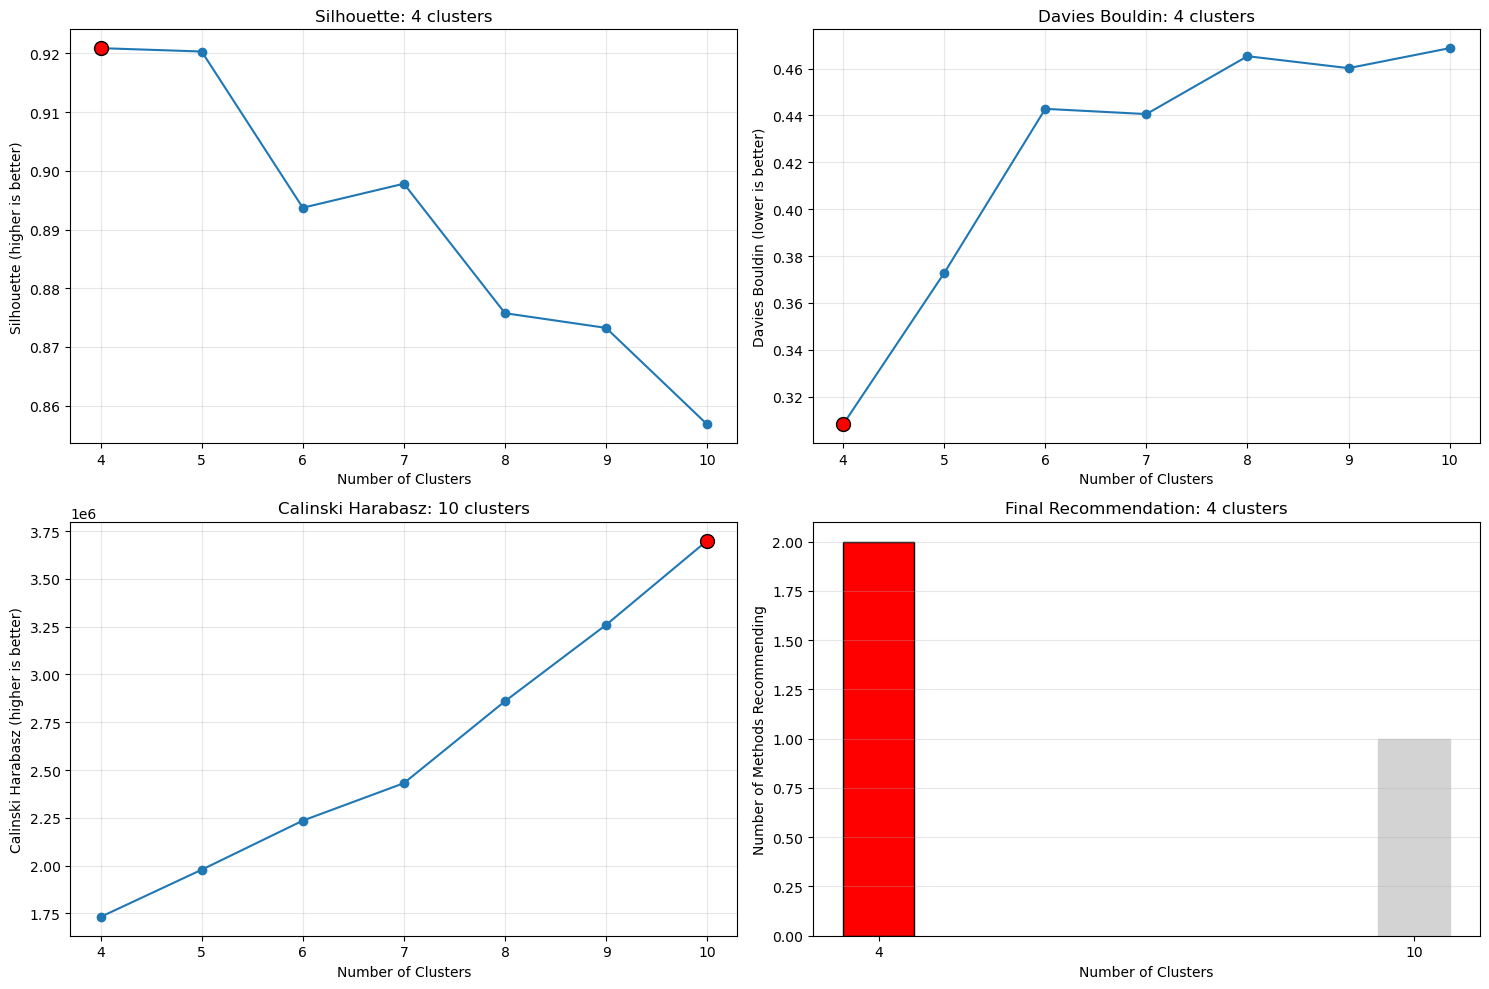


Performing final clustering with 4 clusters...


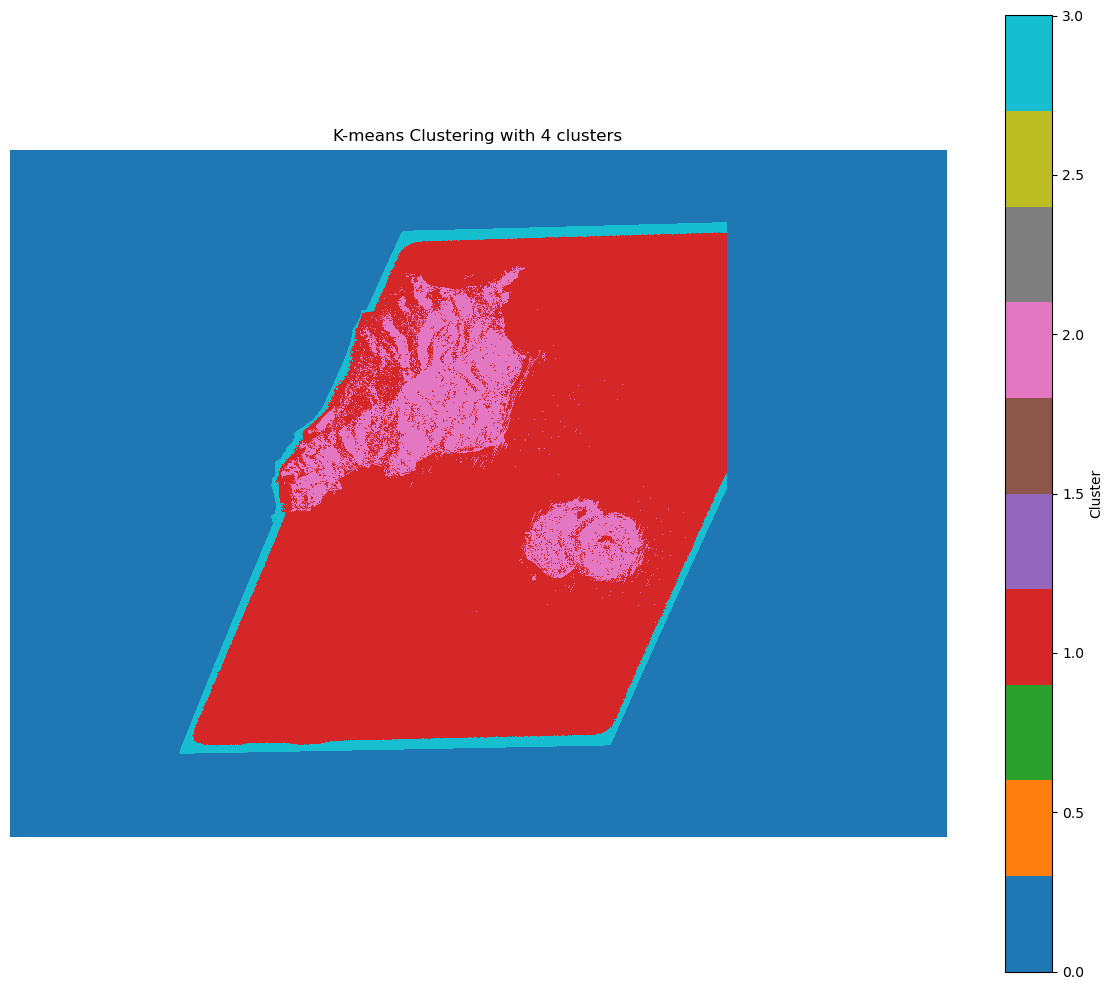

Analyzing statistics for 4 clusters...


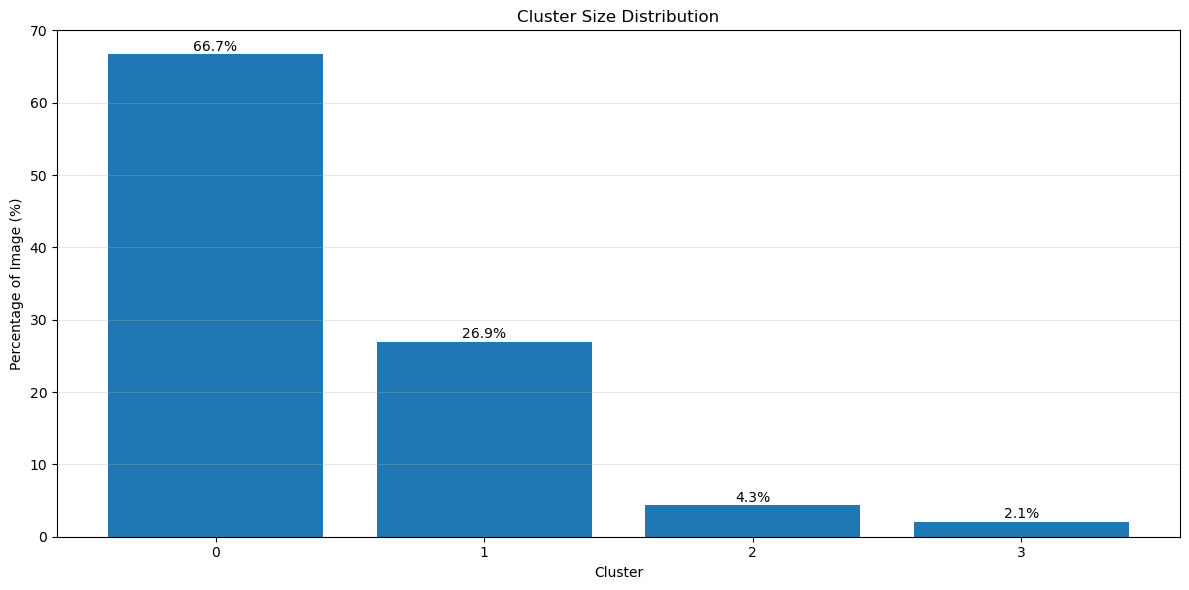

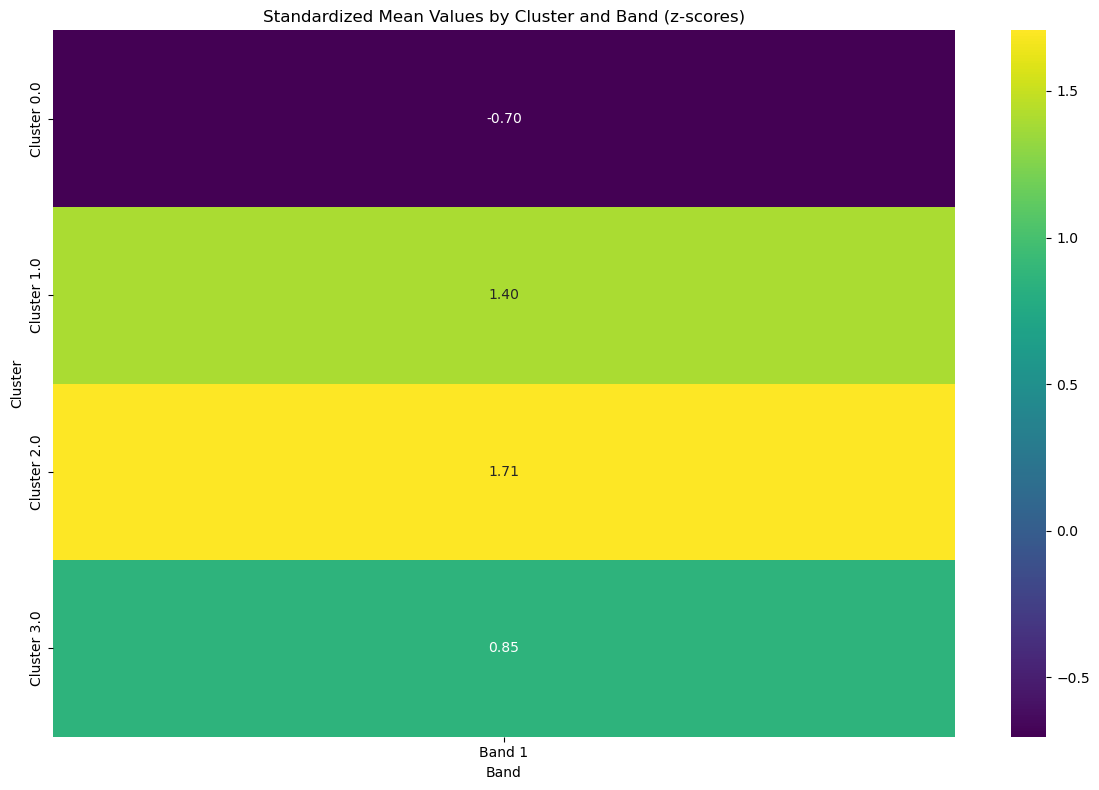

Analyzing 4 clusters across 1 bands...

Cluster Statistics (Average dB values):
Cluster | Pixel Count | Mean dB | Description
--------|-------------|---------|------------
      2 |     4021384 |   -7.44 | HIGHEST
      1 |    25084987 |  -19.20 | 
      3 |     1923203 |  -40.19 | 
      0 |    62116133 | -100.00 | 


/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_15894/3688817449.py:1316: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_clusters)


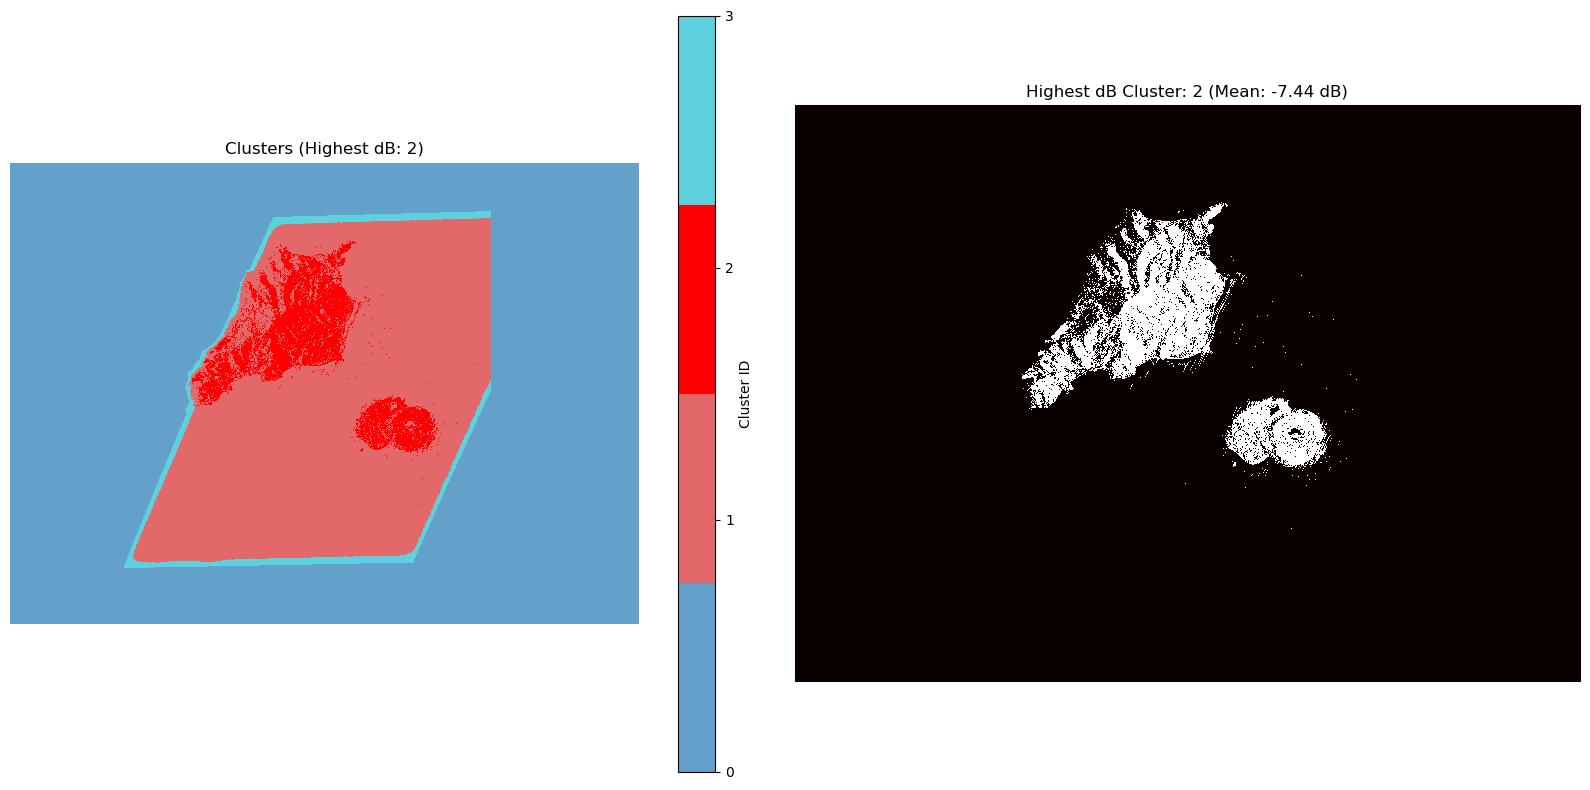

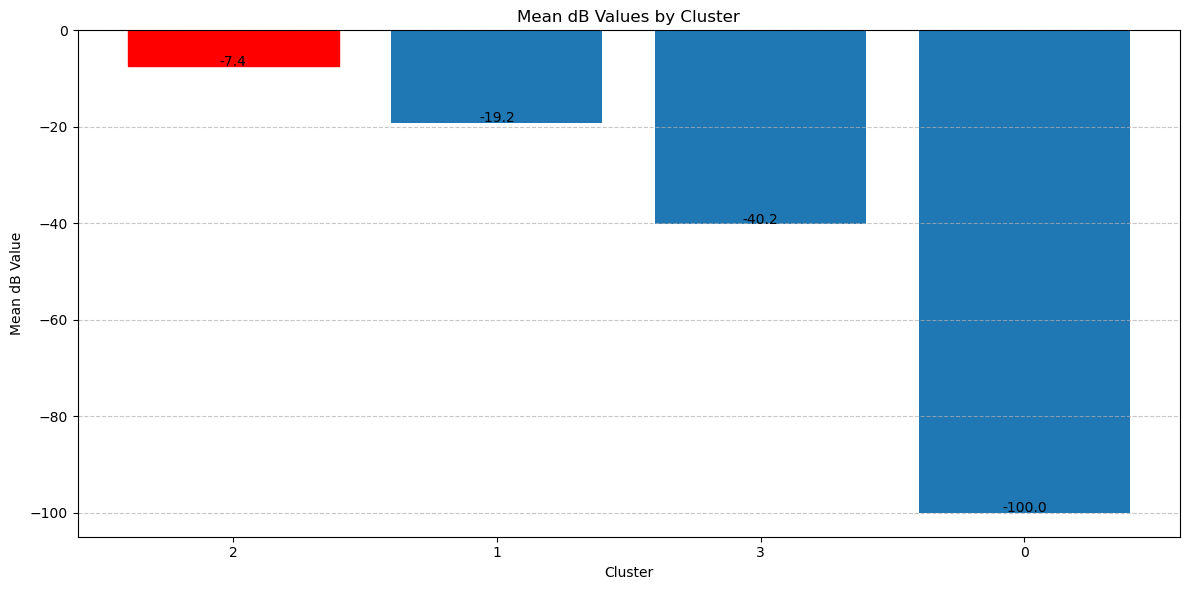

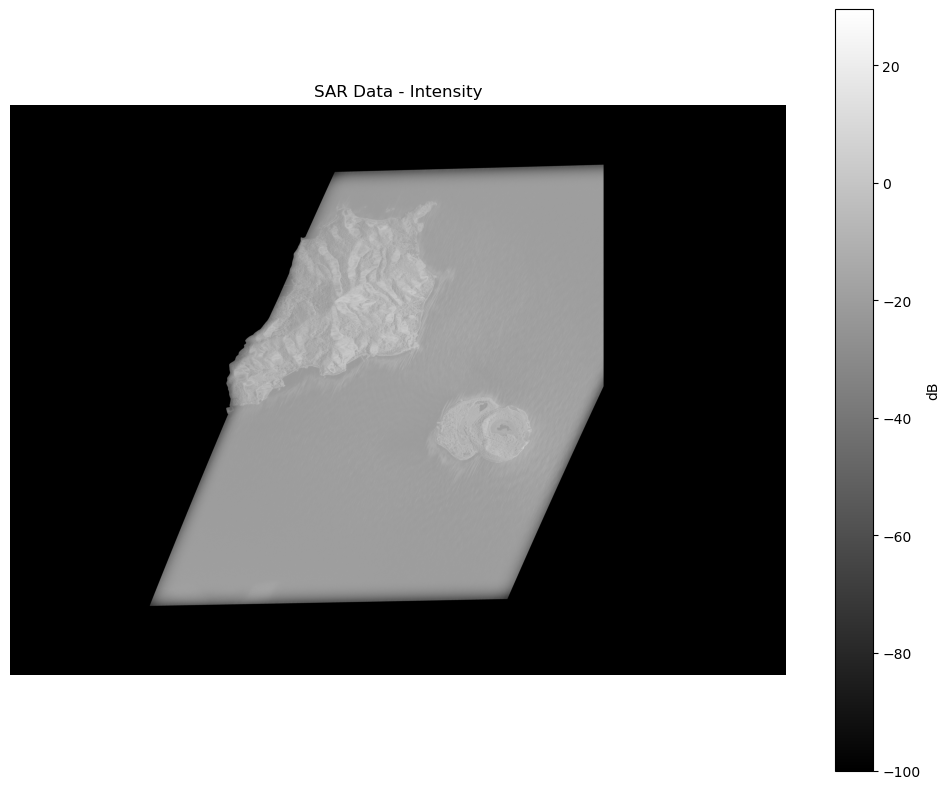

Smoothed binary mask saved to /Users/sahuang/Documents/DATA/umbra/ALL_RTC_INPUT/aunuu_temp/Aunuu_20250522_filt_4_cluster_mask_auto.tif


/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_15894/3577793526.py:135: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  cleaned = morphology.binary_opening(mask, morphology.disk(2))
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_15894/3577793526.py:136: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  cleaned = morphology.binary_closing(cleaned, morphology.disk(2))
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_15894/3577793526.py:141: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  dilated = morphology.binary_dilation(dilated, morphology.disk(3))
/var/folders/xg/d7l0rjhd61v1zgdny285

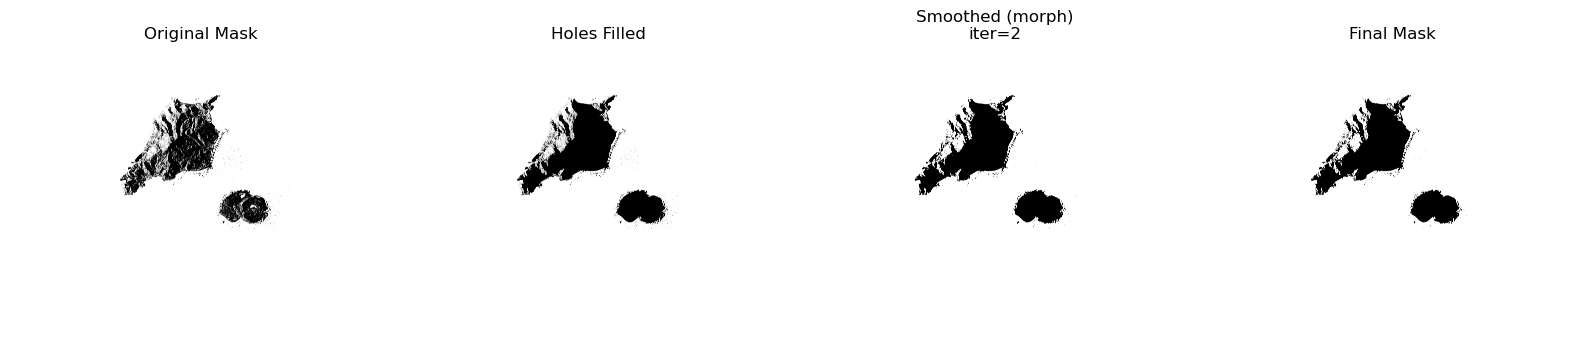

Smoothed binary mask saved to /Users/sahuang/Documents/DATA/umbra/ALL_RTC_INPUT/aunuu_temp/Aunuu_20250522_filt_4_cluster_smoothed_mask_morph_auto.tif
Extracted 10 coastline segments


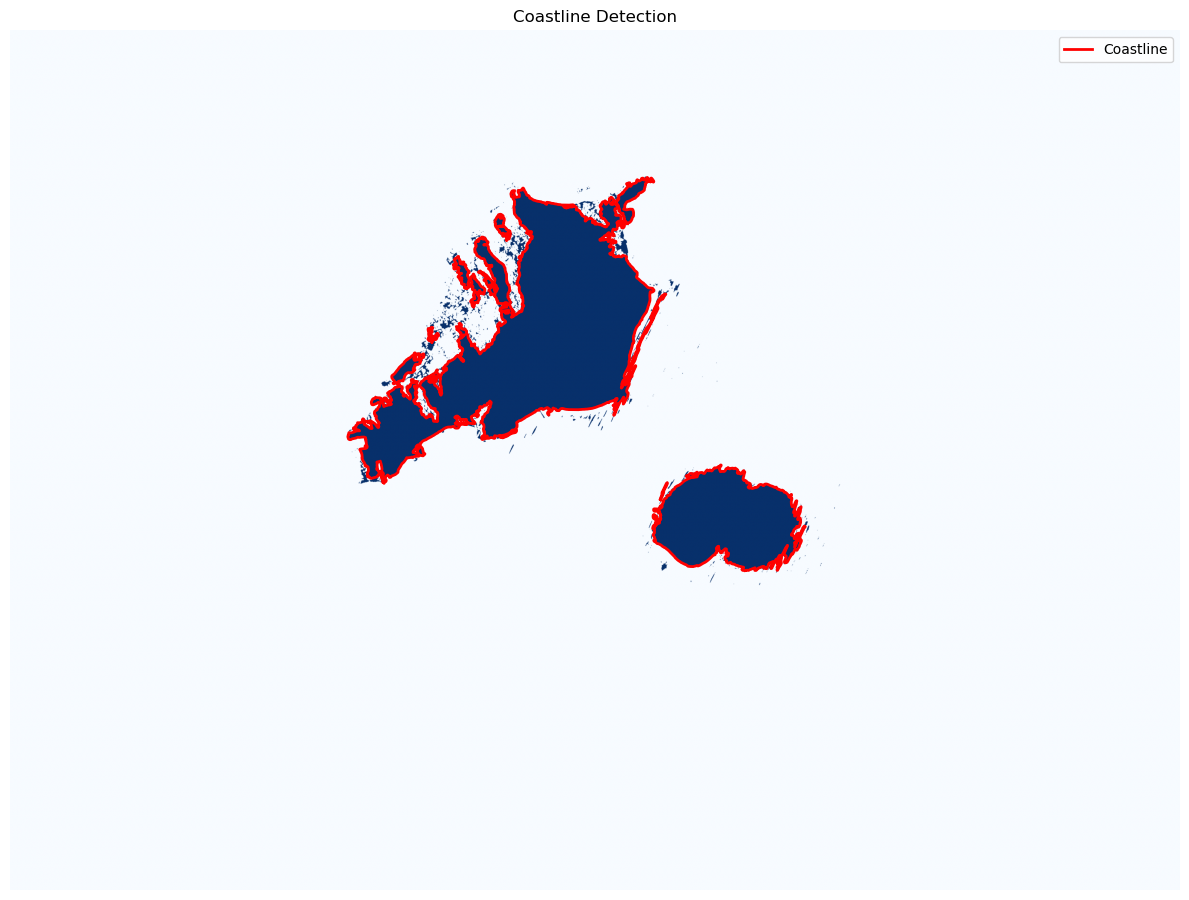

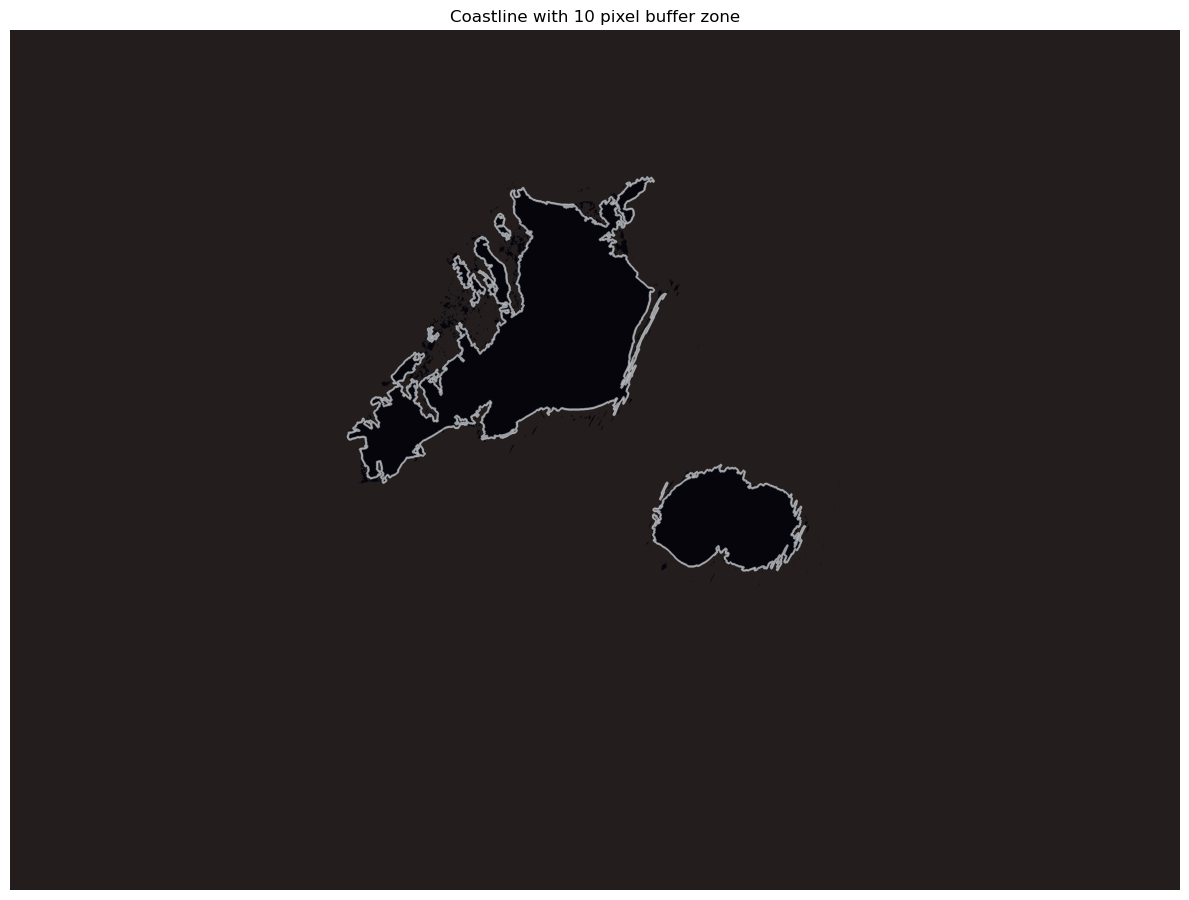

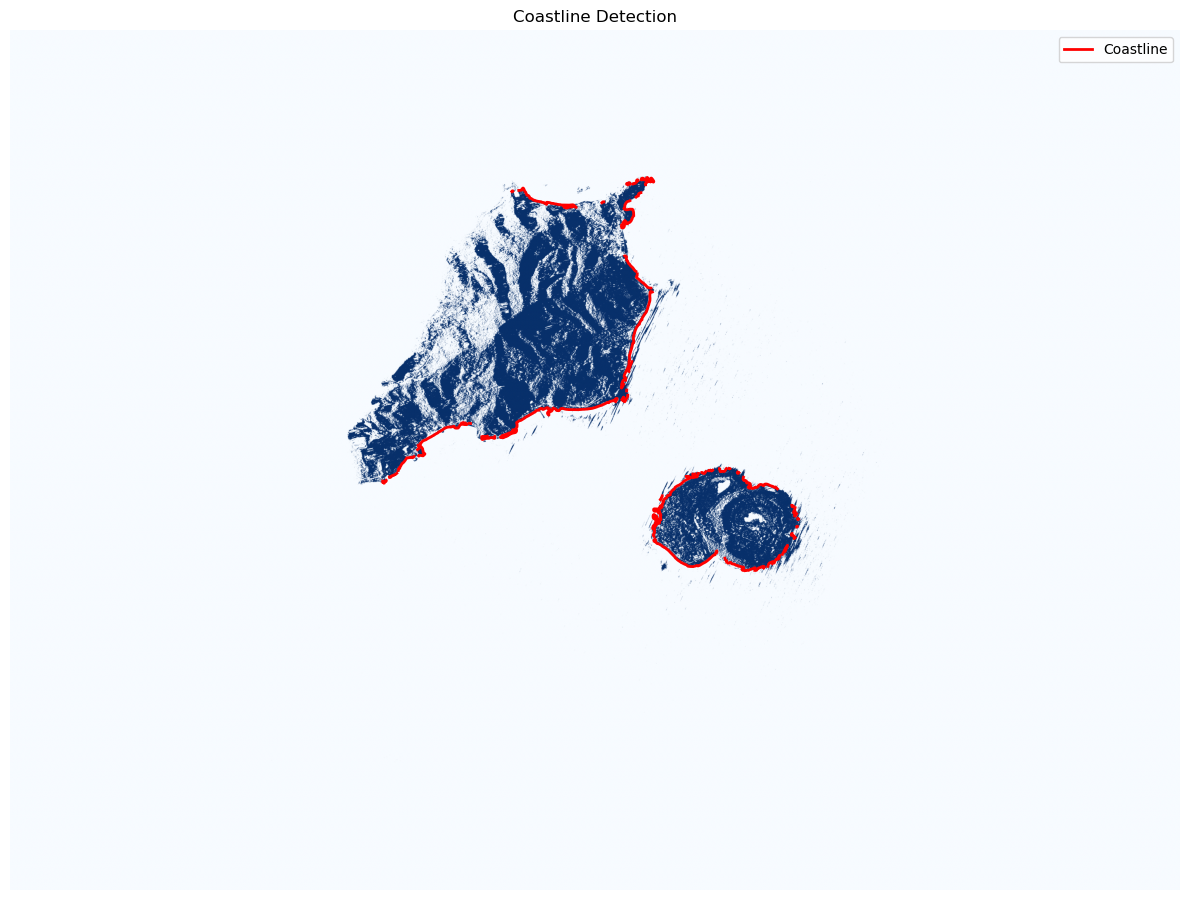

Coastlines saved to /Users/sahuang/Documents/DATA/umbra/ALL_RTC_INPUT/aunuu_temp/Aunuu_20250522_filt_4_cluster_coastline_improved_auto.shp


In [32]:
# Loop over all files in directory
verbose = 0
max_contours = 10 # None
#methods_to_test=['elbow', 'silhouette', 'davies_bouldin']
methods_to_test=['silhouette', 'davies_bouldin', 'calinski_harabasz']
# options: ['elbow', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'gap_statistic']
num_pix_buffer = 30 # relative to the size of the SAR image resolution

filepath = '/Users/sahuang/Documents/DATA/umbra/ALL_RTC_INPUT/'
filenames = os.listdir(filepath)
suffix = 'filt.geo.tif'

# Layover and shadowing mask
filepath_mask = '/Users/sahuang/Documents/DATA/umbra/ALL_MASK/'

for filename in filenames:
    if suffix in filename:
        print('Processing ' + filename + '...')
        filename_base = filename.split('.')[0]
        filename_mask = filepath_mask + filename_base + '.ls_map.rdc.geo.tif'
        if 'filt' in filename:
            filename_base = filename_base + '_filt'
        geotiff_path = filepath + filename
    
        # Load SAR data (already in dB)
        with rasterio.open(geotiff_path) as src:
            sar_data = src.read()
            sar_data = np.moveaxis(sar_data, 0, -1)  # Convert to (height, width, bands)
        
        # Find optimal number of clusters
        optimal_clusters, kmeans_model, clustered_image, stats = cluster_analysis_full_workflow(
            sar_data,
            min_clusters=4,
            max_clusters=10,
            sample_size=10000,
            standardize=True,
            methods_list=methods_to_test
        )
    
        if verbose:
            print(f"Optimal number of clusters: {optimal_clusters}")
    
            results = plot_db_sar_cluster_histograms(
                sar_data,
                clustered_image,
                sample_size=10000,
                bins=50
            )
            
            # Show all plots
            plt.show()
    
        # Select the single cluster with the highest average dB value
        highest_cluster, stats, binary_mask = select_highest_db_cluster(
            sar_data,    # SAR data (already in dB units)
            clustered_image,    # cluster assignment map
            bands=[0],      # Specify bands to use (optional)
            visualize=True,  # Create visualizations
            return_mask=True
        )
    
        if verbose:
            print(f"Cluster with highest dB: {highest_cluster}")
    
        # Save the mask as a GeoTIFF
        output_path = filepath+filename_base+"_"+str(optimal_clusters)+"_cluster_mask_auto.tif"
        save_mask_geotiff(binary_mask, geotiff_path, output_path)
        
        # Fill small holes in the mask
        filled_mask = ndimage.binary_fill_holes(binary_mask)
        
        # Remove small isolated regions
        cleaned_mask = ndimage.binary_opening(binary_mask, structure=np.ones((3,3)))
        
        # Morphological smoothing
        smoothed_mask = process_and_visualize_mask(
            binary_mask, 
            sar_data,
            filling_method='holes', 
            smoothing_method='morph', 
            iterations=2
        )
        
        save_mask_geotiff(smoothed_mask, output_path, filepath+filename_base+"_"+str(optimal_clusters)+"_cluster_smoothed_mask_morph_auto.tif")
        
        # First pass at coastline detection (skip saving)
        coastlines, coastline_gdf = detect_coastline_from_water_mask_improved(
            binary_water_mask=smoothed_mask,
            original_data=sar_data,
            reference_geotiff_path=geotiff_path,
            invert_water_mask=True,
            smooth_boundary=True,
            smooth_sigma=1.5,
            output_shapefile=None,
            buffer_distance=10,  # 10-pixel buffer zone around coastline
            num_contours=max_contours
        )
    
        # Refine coastline detection
        # 1. Align the different-resolution landcover to working SAR grid
        landcover_file = '/Users/sahuang/Documents/DATA/am_samoa/Landcover/am_samoa_ccap_ocean_mask_small.tif'
        aligned_lc = align_landcover_to_base(geotiff_path, landcover_file)
        
        # 2. Create a buffer of allowed pixels (in units of SAR image resolution)
        valid_zone = create_valid_buffer_zone(aligned_lc, buffer_pixels=num_pix_buffer)
        
        # 3. Filter the extracted coastline
        cropped_coastlines = filter_coastline_by_buffer(coastlines, valid_zone)

        # Align the LSM and Create Distortion Mask
        aligned_lsm = align_lsm_to_base(geotiff_path, filename_mask)
        distortion_mask = create_distortion_mask(aligned_lsm)
        
        # Visualize and save coastlines
        visualize_coastlines(binary_mask, cropped_coastlines, sar_data)

        # Remove False Coastlines caused by SAR geometry
        final_coastlines = remove_false_coastlines(cropped_coastlines, distortion_mask)
        
        # Convert coastlines to geospatial coordinates and save
        coastline_gdf = coastlines_to_geospatial(
            final_coastlines, 
            geotiff_path, 
            output_shapefile=filepath+filename_base+"_"+str(optimal_clusters)+"_cluster_coastline_improved_auto.shp"
        )